# Active Inference & Intentional Behaviour: Pong across architectures and learning rules

A **single, self-contained notebook** that runs the Pong experiment of

> Friston, Salvatori, Isomura, Tschantz, Kiefer, Verbelen, et al. (2023)
> *Active Inference and Intentional Behaviour*, [arXiv:2312.07547](https://arxiv.org/abs/2312.07547)

using the network architectures and biologically-plausible learning rules of

> Galloni A.R., Peddada A., Chennawar Y., Milstein A.D. (2026)
> *Cellular and subcellular specialization enables biology-constrained deep learning*,
> [Cell Reports 10.1016/j.celrep.2026.117159](https://doi.org/10.1016/j.celrep.2026.117159) ·
> [github.com/Milstein-Lab/EIANN](https://github.com/Milstein-Lab/EIANN)

**Nothing is installed and no repository is cloned.** The parts of EIANN that this
experiment needs — populations, projections, Dale's law, the relaxation dynamics,
the dendritic compartment, and nine learning rules — are re-implemented from the
published source in Parts 2–3 below. The only dependencies are `torch`, `numpy`
and `matplotlib`, all of which Colab already has.

---

### What you get

| Part | Contents |
|---|---|
| 1 | Setup |
| 2 | Mini-EIANN core: `Population`, `Projection`, `Network`, relaxation dynamics |
| 3 | Learning rules: Backprop, Hebbian, Oja, BCM, dendritic target propagation, supervised Hebbian, contrastive Hebbian, dendritic loss, top-down weight learning |
| 4 | The Pong world of Friston et al. (45° ball, paddle, 3 control states) + oracle |
| 5 | Three architectures: `ann`, `ei` (Dale's law), `ei_dend` (+ dendrites) |
| 6 | Online training and closed-loop evaluation (hit rate, rally length) |
| 7 | Experiment grid, plots, diagnostics |
| 8 | Results, known limitations, and how to push further |

### Honest summary of the results

Backprop solves this task on all three architectures (≈0.87 action accuracy,
perfect closed-loop play). **The local rules, at the hyperparameters shipped here,
do not beat the majority-action baseline.** Part 8 explains why — a diagnostic in
Part 7 measures the cosine between the locally-computed dendritic error and the
error true backprop would deliver, and it sits near zero. This is a real,
measurable finding rather than a silent failure, and the knobs to attack it are
exposed. Please read Part 8 before quoting any number from here.

## Part 1 — Setup

In [ ]:
# Colab already has all of these.  No pip install, no git clone, no Drive mount.
import math, time, random
from collections import OrderedDict

import numpy as np
import torch
import matplotlib.pyplot as plt

SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Everything below runs on tiny tensors one sample at a time (that is how the
# EIANN local rules are defined - they are outer products of 1-D activity
# vectors), so the CPU is faster than the GPU here.  Do not switch to CUDA.
print('torch', torch.__version__)
print('numpy', np.__version__)

torch 2.11.0+cpu
numpy 2.0.2


## Part 2 — A self-contained mini-EIANN core

EIANN organises networks around **populations** of neurons rather than layers of
weights. A `Layer` is a container (think "cortical area") holding one or more
`Population`s; a `Projection` is the weight matrix between two populations, and
carries its own learning rule, sign constraint (Dale's law), direction and target
compartment (soma or dendrite).

Each population is a rate unit with a leaky-integrator state, so a forward pass is
a short **relaxation** rather than a single matrix multiply:

$$\Delta s = -s + b + \sum_p W_p\,a_{\text{pre}(p)}, \qquad
s \leftarrow s + \frac{\Delta s}{\tau}, \qquad
a \leftarrow f(s + d)$$

iterated `forward_steps` times over the layers in order. Feed-forward (`'F'`)
projections read the presynaptic activity of the current step; recurrent (`'R'`)
projections read `prev_activity`, so lateral and top-down loops resolve by
relaxation instead of by an imposed ordering. `d` is the dendritic contribution,
which is zero during the forward phase and carries the plateau signal during the
backward phase.

Weights are held as plain tensors with a hand-rolled Adam/SGD, so the whole thing
depends on nothing but `torch`.

In [ ]:
# =====================================================================
# PART 2 - A self-contained mini-EIANN core
# =====================================================================
# Faithful (but compact) re-implementation of the parts of
# Milstein-Lab/EIANN needed for this experiment.  Vocabulary follows the
# paper: Layers contain Populations, Populations are wired by Projections.
#
# Dynamics (identical to EIANN's forward / backward_update_layer_activity):
#
#     ds  = -s + b + sum_p  W_p @ a_pre(p)
#     s  <- s + ds / tau
#     a  <- f(s + dend_to_soma)
#
# iterated `forward_steps` times over layers in order.  Feedforward ('F')
# projections read the presynaptic activity of the current step, recurrent
# ('R') projections read `prev_activity`, so lateral / top-down loops are
# resolved by relaxation rather than by an explicit ordering.
# ---------------------------------------------------------------------

import math
import torch


# --------------------------- activations -----------------------------
def _linear(x):
    return x


def _softmax(x):
    return torch.softmax(x, dim=-1)


ACTIVATIONS = {
    'linear': _linear,
    'relu': torch.relu,
    'sigmoid': torch.sigmoid,
    'tanh': torch.tanh,
    'softmax': _softmax,
}


# --------------------------- weight inits ----------------------------
def init_weight(shape, scheme='kaiming', scale=1.0, sign=None):
    """sign=None -> unconstrained; sign=+1/-1 -> half-normal, Dale-compliant."""
    fan_in = shape[1]
    w = torch.randn(shape[0], shape[1]) * math.sqrt(2.0 / fan_in) * scale
    if sign is None:
        return w
    return torch.abs(w) * float(sign)


# ----------------------------- optimizer -----------------------------
class Adam:
    """Tiny Adam so the notebook needs nothing beyond torch tensors."""

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.params = list(params)
        self.lr, self.b1, self.b2, self.eps = lr, betas[0], betas[1], eps
        self.m = [torch.zeros(p.shape) for p in self.params]
        self.v = [torch.zeros(p.shape) for p in self.params]
        self.t = 0

    def zero_grad(self):
        for p in self.params:
            p.grad = None

    def step(self):
        self.t += 1
        bc1 = 1 - self.b1 ** self.t
        bc2 = 1 - self.b2 ** self.t
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            g = p.grad
            self.m[i] = self.m[i] * self.b1 + g * (1 - self.b1)
            self.v[i] = self.v[i] * self.b2 + (g * g) * (1 - self.b2)
            mh = self.m[i] / bc1
            vh = self.v[i] / bc2
            p.data -= self.lr * mh / (torch.sqrt(vh) + self.eps)


class SGD:
    def __init__(self, params, lr=1e-2, momentum=0.0):
        self.params = list(params)
        self.lr, self.mu = lr, momentum
        self.buf = [torch.zeros(p.shape) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            p.grad = None

    def step(self):
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            self.buf[i] = self.buf[i] * self.mu + p.grad
            p.data -= self.lr * self.buf[i]


OPTIMIZERS = {'Adam': Adam, 'SGD': SGD}


# ---------------------------- Population -----------------------------
class Population:
    def __init__(self, network, layer, name, size, activation='relu', tau=None,
                 include_bias=False, bias_learning_rule=None, output_pop=False):
        self.network = network
        self.layer = layer
        self.name = name
        self.fullname = f'{layer.name}.{name}'
        self.size = size
        self.activation_name = activation
        self.activation = ACTIVATIONS[activation]
        self.tau = float(tau) if tau is not None else float(network.tau)
        self.include_bias = include_bias
        self.bias_learning_rule = bias_learning_rule
        self.output_pop = output_pop

        self.bias = torch.zeros(size)
        if include_bias and bias_learning_rule == 'Backprop':
            self.bias.requires_grad_(True)

        self.projections = []           # incoming
        self.backward_projections = []  # incoming projections active in phase B
        self.outgoing_projections = []
        self.reinit()

    def __iter__(self):
        return iter(self.projections)

    def __repr__(self):
        return f'<Population {self.fullname} ({self.size})>'

    # ---- state ----
    def reinit(self):
        self.state = torch.zeros(self.size)
        self.activity = torch.zeros(self.size)
        self.prev_activity = torch.zeros(self.size)
        self.forward_activity = torch.zeros(self.size)
        self.forward_prev_activity = torch.zeros(self.size)
        self.dendritic_state = torch.zeros(self.size)
        self.dendritic_state_raw = torch.zeros(self.size)
        self.forward_dendritic_state = torch.zeros(self.size)
        self.forward_dendritic_state_raw = torch.zeros(self.size)
        self.plateau = torch.zeros(self.size)
        if hasattr(self, 'dend_to_soma'):
            del self.dend_to_soma

    def has_dend(self):
        return any(p.compartment == 'dend' for p in self.projections)

    # ---- one relaxation step of the somatic compartment ----
    def forward_step(self):
        delta_state = -self.state + self.bias
        for proj in self.projections:
            if proj.compartment in (None, 'soma'):
                if proj.direction in ('forward', 'F'):
                    delta_state = delta_state + proj(proj.pre.activity)
                else:
                    delta_state = delta_state + proj(proj.pre.prev_activity)
        self.state = self.state + delta_state / self.tau
        if hasattr(self, 'dend_to_soma'):
            self.activity = self.activation(self.state + self.dend_to_soma)
        else:
            self.activity = self.activation(self.state)

    def compute_dendritic_state(self):
        init = False
        for proj in self.projections:
            if proj.compartment == 'dend':
                if not init:
                    self.dendritic_state = torch.zeros(self.size)
                    init = True
                if proj.direction in ('forward', 'F'):
                    self.dendritic_state = self.dendritic_state + proj(proj.pre.activity)
                else:
                    self.dendritic_state = self.dendritic_state + proj(proj.pre.prev_activity)
        if init:
            self.dendritic_state_raw = self.dendritic_state
            self.dendritic_state = torch.clamp(self.dendritic_state, min=-1., max=1.)
        return init


class InputPopulation(Population):
    def __init__(self, network, layer, name, size):
        super().__init__(network, layer, name, size, activation='linear')

    def forward_step(self):
        pass


# ------------------------------ Layer --------------------------------
class Layer:
    def __init__(self, network, name):
        self.network = network
        self.name = name
        self.populations = []

    def append(self, pop):
        self.populations.append(pop)
        setattr(self, pop.name, pop)

    def __iter__(self):
        return iter(self.populations)

    def __repr__(self):
        return f'<Layer {self.name}: {[p.name for p in self.populations]}>'


# ---------------------------- Projection -----------------------------
class Projection:
    """A weight matrix (post.size, pre.size) plus its metadata + learning rule."""

    def __init__(self, pre, post, sign=None, init_scale=1.0, direction='F',
                 compartment=None, update_phase='F', learning_rule=None,
                 learning_rule_kwargs=None, weight_constraint=None):
        self.pre, self.post = pre, post
        self.name = f'{post.fullname}<-{pre.fullname}'
        self.sign = sign
        self.direction = direction
        self.compartment = compartment
        self.update_phase = update_phase
        self.weight_constraint = weight_constraint

        self.weight = init_weight((post.size, pre.size), scale=init_scale, sign=sign)
        self.initial_row_norm = torch.sqrt((self.weight * self.weight).sum() /
                                           self.weight.shape[0]) + 1e-8

        self.learning_rule = None
        if learning_rule is not None:
            kw = dict(learning_rule_kwargs or {})
            self.learning_rule = RULES[learning_rule](self, **kw)
            if isinstance(self.learning_rule, Backprop):
                self.weight.requires_grad_(True)

        post.projections.append(self)
        pre.outgoing_projections.append(self)
        if update_phase in ('B', 'backward', 'A', 'all'):
            post.backward_projections.append(self)

    def __call__(self, x):
        return self.weight @ x

    def __repr__(self):
        rule = type(self.learning_rule).__name__ if self.learning_rule else 'None'
        return f'<Projection {self.name} [{self.weight.shape}] {rule}>'

    # ---- constraints applied after every update ----
    def constrain(self):
        if self.sign is not None:
            if self.sign > 0:
                self.weight.data.clamp_(min=0.)
            else:
                self.weight.data.clamp_(max=0.)
        if self.weight_constraint == 'normalize':
            # rescale so the mean row norm matches its value at initialisation
            cur = torch.sqrt((self.weight.data * self.weight.data).sum() /
                             self.weight.shape[0]) + 1e-8
            self.weight.data *= (self.initial_row_norm / cur).item()


# ----------------------------- Network -------------------------------
class Network:
    """Ordered stack of Layers; layer 0 must hold the Input population."""

    def __init__(self, layer_config, projection_config, learning_rate=1e-3,
                 tau=1, forward_steps=1, backward_steps=1,
                 optimizer='Adam', seed=None, criterion='MSE'):
        if seed is not None:
            torch.manual_seed(seed)
        self.learning_rate = learning_rate
        self.tau = tau
        self.forward_steps = forward_steps
        self.backward_steps = backward_steps
        self.criterion_name = criterion

        self.layers = []
        self.populations = {}
        self.projections = []

        # ---- build populations ----
        for li, (layer_name, pops) in enumerate(layer_config.items()):
            layer = Layer(self, layer_name)
            for pop_name, kw in pops.items():
                kw = dict(kw)
                if li == 0:
                    pop = InputPopulation(self, layer, pop_name, kw['size'])
                else:
                    pop = Population(self, layer, pop_name, kw.pop('size'), **kw)
                layer.append(pop)
                self.populations[pop.fullname] = pop
            self.layers.append(layer)
            setattr(self, layer_name, layer)

        self.input_pop = self.layers[0].populations[0]
        self.output_pop = self.layers[-1].populations[0]
        self.output_pop.output_pop = True

        # ---- build projections ----
        for (src, dst), kw in projection_config.items():
            proj = Projection(self.populations[src], self.populations[dst], **kw)
            self.projections.append(proj)

        # ---- autograd bookkeeping ----
        self.autograd_params = [p.weight for p in self.projections
                                if isinstance(p.learning_rule, Backprop)]
        self.autograd_params += [pop.bias for pop in self.populations.values()
                                 if pop.include_bias and pop.bias_learning_rule == 'Backprop']
        self.uses_autograd = len(self.autograd_params) > 0
        self.optimizer = (OPTIMIZERS[optimizer](self.autograd_params, lr=learning_rate)
                          if self.uses_autograd else None)

        # ---- which class-level backward() passes have to run ----
        self.backward_methods = []
        for proj in self.projections:
            rule = proj.learning_rule
            if rule is None:
                continue
            fn = getattr(type(rule).backward, '__func__', type(rule).backward)
            base = getattr(LearningRule.backward, '__func__', LearningRule.backward)
            if fn is base:
                continue
            if not any(fn is getattr(f, '__func__', f) for f in self.backward_methods):
                self.backward_methods.append(type(rule).backward)

        self.constrain()
        self.history = {'loss': [], 'val_loss': [], 'val_acc': [], 'step': []}

    # ---- introspection ----
    def __iter__(self):
        return iter(self.layers)

    def describe(self):
        lines = ['Network', '  Populations:']
        for name, p in self.populations.items():
            lines.append(f'    {name:<14} n={p.size:<5} act={p.activation_name:<8} tau={p.tau}')
        lines.append('  Projections:')
        for p in self.projections:
            rule = type(p.learning_rule).__name__ if p.learning_rule else '-'
            sgn = {1: 'Exc', -1: 'Inh', None: 'free'}[p.sign]
            comp = p.compartment or 'soma'
            lines.append(f'    {p.name:<30} {str(tuple(p.weight.shape)):<12} '
                         f'{sgn:<5} {p.direction} ->{comp:<5} {rule}')
        return '\n'.join(lines)

    def constrain(self):
        for proj in self.projections:
            proj.constrain()

    def reinit(self):
        for pop in self.populations.values():
            pop.reinit()

    # ---- forward relaxation ----
    def forward(self, sample):
        self.reinit()
        self.input_pop.activity = sample
        for _ in range(self.forward_steps):
            for layer in self.layers[1:]:
                for pop in layer:
                    pop.prev_activity = pop.activity
                for pop in layer:
                    pop.forward_step()
        self.update_forward_state()
        return self.output_pop.activity

    def update_forward_state(self):
        """Snapshot forward activities and the forward dendritic state."""
        for pop in self.populations.values():
            pop.forward_activity = pop.activity.detach()
            pop.forward_prev_activity = pop.prev_activity.detach()
        for layer in self.layers[1:]:
            for pop in layer:
                if pop.compute_dendritic_state():
                    pop.forward_dendritic_state = pop.dendritic_state.detach().clone()
                    pop.forward_dendritic_state_raw = pop.dendritic_state_raw.detach().clone()

    # ---- loss ----
    def criterion(self, output, target):
        d = output - target
        return (d * d).mean()

    # ---- one online training step (EIANN trains sample-by-sample) ----
    def train_step(self, sample, target):
        if self.uses_autograd:
            output = self.forward(sample)
            loss = self.criterion(output, target)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            loss_val = loss.item()
            output = output.detach()
        else:
            with torch.no_grad():
                output = self.forward(sample)
                loss_val = self.criterion(output, target).item()

        with torch.no_grad():
            for pop in self.populations.values():
                pop.BCM_theta_updated = False
            for bw in self.backward_methods:
                bw(self, output, target)
            for proj in self.projections:
                if proj.learning_rule is not None:
                    proj.learning_rule.update()
            for proj in self.projections:
                if proj.learning_rule is not None:
                    proj.learning_rule.step()
        self.constrain()
        return loss_val

    def predict(self, sample):
        with torch.no_grad():
            return self.forward(sample)

## Part 3 — Learning rules

Every rule is **local**: `step()` may only use quantities available at the synapse
— pre- and post-synaptic rate, the post-synaptic dendritic state, and the current
weight. What turns a *target* into locally visible signals is the class-level
`backward()`, which runs once per training sample and does two things:

1. **nudges** the output population toward the target (`dend_to_soma`), and
2. lets each hidden layer read the resulting change in top-down drive off its
   dendrite, and emit **plateau events** in a bounded fraction of units.

Rules implemented (transcribed from `EIANN/rules/hebbian.py` and
`EIANN/rules/backprop_like.py`):

| class | supervised? | needs dendrites? | notes |
|---|---|---|---|
| `Backprop` | ✓ | – | baseline; autograd through the unrolled relaxation |
| `Hebb_WeightNorm` | ✗ | – | `ΔW = η·post·preᵀ`; **unbounded on its own** — pair with `weight_constraint='normalize'` |
| `Ojas_rule` | ✗ | – | `ΔW = η(yx − y²W)`, self-normalising |
| `BCM` | ✗ | – | sliding threshold `θ` |
| `Top_Layer_BP_like` | ✓ | – | delta rule at the output projection |
| `BP_like_1E` | ✓ | ✓ | dendritic target prop; error = *change* in dendritic state |
| `BP_like_2E` | ✓ | ✓ | error read straight off the dendrite (needs Dend-I cancellation) |
| `Supervised_Hebb_WeightNorm` | ✓ | ✓ | Hebbian on post-nudge rates |
| `Hebbian_Temporal_Contrast` | ✓ | ✓ | contrastive Hebbian (Xie & Seung 2003) |
| `Dendritic_Loss` | – | ✓ | trains Dend-I→E(dend) to cancel top-down excitation |
| `Top_Down_Hebbian_Temporal_Contrast` | – | ✓ | trains the top-down weights toward `W_forwardᵀ` |

> **This is the single biggest bug in the original notebook.** `Hebb_WeightNorm`,
> `Ojas_rule` and `BCM_4` never see the target — they are purely unsupervised. Applying
> them to the *output* projection, as the original did, leaves no path at all from the
> label to the weights. Here the output projection always carries a supervised rule.

In [ ]:
# =====================================================================
# PART 3 - Learning rules (re-implemented from Galloni et al.)
# =====================================================================
# Every rule is local: `step()` may only look at quantities available at
# the synapse (pre/post activity, the post-synaptic dendritic state, the
# current weight).  The optional class-level `backward()` runs once per
# training sample and is what turns a target into locally-visible signals
# (a somatic "nudge" at the output, and dendritic plateau events in the
# hidden layers).
# ---------------------------------------------------------------------

import math
import torch


class LearningRule:
    def __init__(self, projection, learning_rate=None):
        self.projection = projection
        if learning_rate is None:
            learning_rate = projection.post.network.learning_rate
        self.learning_rate = learning_rate

    def step(self):
        """Local weight update."""

    def update(self):
        """Slow state variables (e.g. the BCM threshold)."""

    @classmethod
    def backward(cls, network, output, target):
        """Network-level pass that makes the target locally available."""


# ------------------------------------------------------------------ #
# 0. Backprop (baseline).  The update itself is done by autograd +
#    optimizer inside Network.train_step; this class is just a marker.
# ------------------------------------------------------------------ #
class Backprop(LearningRule):
    pass


# ------------------------------------------------------------------ #
# 1. Unsupervised Hebbian family
# ------------------------------------------------------------------ #
class Hebb_WeightNorm(LearningRule):
    """dW = lr * sign * outer(clamp(post), clamp(pre)).

    Unbounded on its own - pair it with weight_constraint='normalize',
    which is what the "WeightNorm" in the name refers to.
    """

    def __init__(self, projection, sign=1, learning_rate=None, forward_only=False):
        super().__init__(projection, learning_rate)
        self.sign = sign
        self.forward_only = forward_only

    def step(self):
        p = self.projection
        post = p.post.forward_activity if self.forward_only else p.post.activity
        if p.direction in ('forward', 'F'):
            pre = p.pre.forward_activity if self.forward_only else p.pre.activity
        else:
            pre = p.pre.forward_prev_activity if self.forward_only else p.pre.prev_activity
        dW = torch.outer(torch.clamp(post, min=0, max=1),
                         torch.clamp(pre, min=0, max=1))
        p.weight.data += (self.learning_rate * self.sign) * dW


class Ojas_rule(LearningRule):
    """dW = lr * (y*x - y^2 * W)  (Oja 1982) - self-normalising Hebbian."""

    def __init__(self, projection, learning_rate=None, forward_only=False):
        super().__init__(projection, learning_rate)
        self.forward_only = forward_only

    def step(self):
        p = self.projection
        post = torch.clamp(p.post.forward_activity if self.forward_only
                           else p.post.activity, min=0, max=1)
        if p.direction in ('forward', 'F'):
            pre = p.pre.forward_activity if self.forward_only else p.pre.activity
        else:
            pre = p.pre.forward_prev_activity if self.forward_only else p.pre.prev_activity
        pre = torch.clamp(pre, min=0, max=1)
        hebb = torch.outer(post, pre)
        decay = (post.unsqueeze(1) ** 2) * p.weight.data
        p.weight.data += self.learning_rate * (hebb - decay)


class BCM(LearningRule):
    """Bienenstock-Cooper-Munro with a sliding threshold theta.

        dtheta = (-theta + y^2 / k) / theta_tau
        dW     = lr * sign * outer(y * (y - theta), clamp(pre))
    """

    def __init__(self, projection, theta_tau=100., k=0.1, sign=1, learning_rate=None):
        super().__init__(projection, learning_rate)
        self.theta_tau = theta_tau
        self.k = k
        self.sign = sign
        post = projection.post
        if not hasattr(post, 'theta'):
            post.theta = torch.ones(post.size) * k
        post.BCM_theta_updated = False

    def update(self):
        post = self.projection.post
        if not getattr(post, 'BCM_theta_updated', False):
            post.theta += ((-post.theta + post.activity ** 2. / self.k) / self.theta_tau)
            post.BCM_theta_updated = True

    def step(self):
        p = self.projection
        post = p.post.activity
        pre = p.pre.activity if p.direction in ('forward', 'F') else p.pre.prev_activity
        dW = torch.outer(post, torch.clamp(pre, min=0, max=1)) * \
            (post - p.post.theta).unsqueeze(1)
        p.weight.data += (self.learning_rate * self.sign) * dW


# ------------------------------------------------------------------ #
# 2. Shared backward machinery for the "nudge + plateau" rules
# ------------------------------------------------------------------ #
def _nudge_output(network, target, relu_gate=False):
    """Clamp the output population toward the target and store the error."""
    out = network.output_pop
    local_loss = torch.clamp(target - out.activity, min=-1., max=1.)
    if relu_gate:
        local_loss = local_loss * (out.forward_activity > 0).float()
    out.dendritic_state = local_loss.detach().clone()
    out.plateau = local_loss.detach().clone()
    out.dend_to_soma = local_loss.detach().clone()
    out.prev_activity = out.activity
    out.activity = out.activation(out.state + out.dend_to_soma)


def _select_plateau_units(pop, local_loss, max_pop_fraction, stochastic):
    """A fixed maximum fraction of the population receives a plateau event."""
    max_units = max(1, math.ceil(max_pop_fraction * pop.size))

    pos = (local_loss > 0.).nonzero().squeeze(1)
    if pos.numel() > 0:
        if stochastic:
            rel = torch.bernoulli(local_loss[pos]).nonzero().squeeze(1)
        else:
            _, rel = torch.sort(local_loss[pos], descending=True)
        idx = pos[rel][:max_units]
        pop.plateau[idx] = local_loss[idx]
        pop.dend_to_soma[idx] = local_loss[idx]

    neg = (local_loss < 0.).nonzero().squeeze(1)
    if neg.numel() > 0:
        if stochastic:
            rel = torch.bernoulli(-local_loss[neg]).nonzero().squeeze(1)
        else:
            _, rel = torch.sort(local_loss[neg], descending=True)
        idx = neg[rel][-max_units:]
        pop.plateau[idx] = local_loss[idx]
        pop.dend_to_soma[idx] = local_loss[idx]


def _init_backward(network):
    for layer in network.layers[1:]:
        for pop in layer:
            pop.plateau = torch.zeros(pop.size)
            pop.dend_to_soma = torch.zeros(pop.size)


class Top_Layer_BP_like(LearningRule):
    """Delta rule at the output projection: dW = lr * (target - y) x^T.

    Local: the post-synaptic error is delivered as a somatic nudge, the
    pre-synaptic term is the ordinary firing rate.
    """

    def __init__(self, projection, learning_rate=None, relu_gate=False):
        super().__init__(projection, learning_rate)
        self.relu_gate = relu_gate

    @classmethod
    def backward(cls, network, output, target):
        _init_backward(network)
        _nudge_output(network, target)

    def step(self):
        p = self.projection
        pre = p.pre.forward_activity if p.direction in ('forward', 'F') \
            else p.pre.forward_prev_activity
        dW = torch.outer(p.post.plateau, torch.clamp(pre, min=0, max=1))
        p.weight.data += self.learning_rate * dW


class BP_like_1E(Top_Layer_BP_like):
    """Dendritic target propagation.

    The output is nudged toward the target; the change this induces in the
    top-down drive onto each hidden dendrite
    (`dendritic_state - forward_dendritic_state`) is the local error.  A
    bounded fraction of units then emits a plateau, which both nudges the
    soma and gates the weight update.
    """

    def __init__(self, projection, max_pop_fraction=1., stochastic=False,
                 learning_rate=None, relu_gate=False):
        LearningRule.__init__(self, projection, learning_rate)
        self.max_pop_fraction = max_pop_fraction
        self.stochastic = stochastic
        self.relu_gate = relu_gate

    @classmethod
    def _hidden_local_loss(cls, pop):
        return torch.clamp(pop.dendritic_state - pop.forward_dendritic_state,
                           min=-1., max=1.)

    @classmethod
    def backward(cls, network, output, target):
        """Backward phase.

        t = 0 : the output is nudged toward the target; layer by layer,
                top-down drive is re-read off the dendrites, a bounded
                fraction of units emits a plateau, and the soma is nudged.
        t > 0 : the whole network re-equilibrates with the nudges held
                fixed (`backward_steps`).

        Within a layer the interneurons are relaxed *before* the dendritic
        state of the E population is read.  EIANN updates them afterwards;
        doing it first is what lets the Dend-I population contribute a
        signed component to the local error instead of lagging a step
        behind (see the "Deviations" note at the end of the notebook).
        """
        _init_backward(network)
        out = network.output_pop
        rules = {}
        for layer in network.layers[1:]:
            for pop in layer:
                rules[pop.fullname] = next(
                    (p.learning_rule for p in pop.projections
                     if isinstance(p.learning_rule, cls)), None)

        _nudge_output(network, target,
                      getattr(rules.get(out.fullname), 'relu_gate', False))

        for t in range(max(1, network.backward_steps)):
            for layer in reversed(network.layers[1:]):
                for pop in layer:
                    pop.prev_activity = pop.activity
                # 1. interneurons follow the nudge
                for pop in layer:
                    if pop is out or pop.has_dend():
                        continue
                    pop.forward_step()
                # 2. dendrites read the (changed) top-down drive
                for pop in layer:
                    if pop.has_dend():
                        pop.compute_dendritic_state()
                # 3. plateau events, once
                if t == 0:
                    for pop in layer:
                        rule = rules.get(pop.fullname)
                        if rule is None or pop is out:
                            continue
                        ll = cls._hidden_local_loss(pop)
                        if rule.relu_gate:
                            ll = ll * (pop.forward_activity > 0).float()
                        _select_plateau_units(pop, ll, rule.max_pop_fraction,
                                              rule.stochastic)
                # 4. principal cells integrate soma + plateau
                for pop in layer:
                    if pop is out or not pop.has_dend():
                        continue
                    pop.forward_step()

    def step(self):
        p = self.projection
        pre = p.pre.forward_activity if p.direction in ('forward', 'F') \
            else p.pre.forward_prev_activity
        dW = torch.outer(p.post.plateau, torch.clamp(pre, min=0, max=1))
        p.weight.data += self.learning_rate * dW


class BP_like_2E(BP_like_1E):
    """As BP_like_1E, but the hidden error is read straight off the dendrite.

    This assumes the Dend-I population has learned to cancel the top-down
    excitation during the forward phase (see `Dendritic_Loss`), so that any
    residual dendritic state *is* the error.
    """

    @classmethod
    def _hidden_local_loss(cls, pop):
        return torch.clamp(pop.dendritic_state, min=-1., max=1.)


class Supervised_Hebb_WeightNorm(BP_like_2E):
    """Hebbian, but on activities that have been nudged by the target.

    Same backward pass as BP_like_2E; the update is the plain (bounded)
    Hebbian product of the post-nudge rates rather than the plateau.
    """

    def __init__(self, projection, sign=1, max_pop_fraction=0.05, stochastic=True,
                 learning_rate=None, relu_gate=False):
        BP_like_1E.__init__(self, projection, max_pop_fraction, stochastic,
                            learning_rate, relu_gate)
        self.sign = sign

    def step(self):
        p = self.projection
        pre = p.pre.activity if p.direction in ('forward', 'F') else p.pre.prev_activity
        dW = torch.outer(torch.clamp(p.post.activity, min=0, max=1),
                         torch.clamp(pre, min=0, max=1))
        p.weight.data += (self.learning_rate * self.sign) * dW


class Hebbian_Temporal_Contrast(BP_like_2E):
    """Contrastive Hebbian (Xie & Seung 2003):
    dW = lr * (post_nudged x pre_nudged  -  post_forward x pre_forward)."""

    def step(self):
        p = self.projection
        fpost = torch.clamp(p.post.forward_activity, min=0, max=1)
        bpost = torch.clamp(p.post.activity, min=0, max=1)
        if self.relu_gate:
            bpost = bpost * (fpost > 0).float()
        if p.direction in ('forward', 'F'):
            fpre = torch.clamp(p.pre.forward_activity, min=0, max=1)
            bpre = torch.clamp(p.pre.activity, min=0, max=1)
        else:
            fpre = torch.clamp(p.pre.forward_prev_activity, min=0, max=1)
            bpre = torch.clamp(p.pre.prev_activity, min=0, max=1)
        dW = torch.outer(bpost, bpre) - torch.outer(fpost, fpre)
        p.weight.data += self.learning_rate * dW


# ------------------------------------------------------------------ #
# 3. Learning the dendritic inhibition (Galloni et al., Fig. 4)
# ------------------------------------------------------------------ #
class Dendritic_Loss(LearningRule):
    """Trains Dend-I -> E(dend) weights to cancel top-down excitation
    during the forward phase, so that the dendrite reports ~0 when the
    network is not being nudged, and reports the error when it is."""

    def step(self):
        p = self.projection
        dW = torch.outer(p.post.forward_dendritic_state_raw,
                         torch.clamp(p.pre.forward_activity, min=0, max=1))
        p.weight.data -= self.learning_rate * dW


class Top_Down_Hebbian_Temporal_Contrast(LearningRule):
    """Learns the top-down (dendrite-targeting) weights so that they come to
    mirror the forward weights - Galloni et al.'s answer to the fact that a
    *fixed* random feedback pathway cannot align with Dale-constrained
    forward weights.

        dW = lr * outer(post_forward_activity,
                        clamp(pre_backward - pre_forward, -1, 1))

    i.e. a top-down synapse strengthens when the lower-layer cell was active
    and the upper-layer cell increased its rate during the nudge.  Averaged
    over samples this drives W_topdown toward W_forward^T (Xie & Seung 2003).
    """

    def step(self):
        p = self.projection
        post = torch.clamp(p.post.forward_activity, min=0, max=1)
        if p.direction in ('forward', 'F'):
            fpre, bpre = p.pre.forward_activity, p.pre.activity
        else:
            fpre, bpre = p.pre.forward_prev_activity, p.pre.prev_activity
        dW = torch.outer(post, torch.clamp(bpre - fpre, min=-1., max=1.))
        p.weight.data += self.learning_rate * dW


RULES = {
    'Backprop': Backprop,
    'Hebb_WeightNorm': Hebb_WeightNorm,
    'Ojas_rule': Ojas_rule,
    'BCM': BCM,
    'Top_Layer_BP_like': Top_Layer_BP_like,
    'BP_like_1E': BP_like_1E,
    'BP_like_2E': BP_like_2E,
    'Supervised_Hebb_WeightNorm': Supervised_Hebb_WeightNorm,
    'Hebbian_Temporal_Contrast': Hebbian_Temporal_Contrast,
    'Dendritic_Loss': Dendritic_Loss,
    'Top_Down_Hebbian_Temporal_Contrast': Top_Down_Hebbian_Temporal_Contrast,
}

## Part 4 — The Pong world of Friston et al.

From the paper:

> *"a ball bounced around a box at 45 degrees. The lower boundary contained a
> paddle that could be moved to the right or left. The size of the box was 5 × 6
> units, where the ball moved one unit up or down (and right or left) at every
> time point."*

The agent has three control states (left / stay / right), the box is 30 pixels,
and the paper reports two difficulties: **easy** (6×5) and **hard** (8×4).

### One important departure

The paper's observation is a **single** 30-pixel frame. A single frame does not
determine which way the ball is travelling — the discrete active-inference agent
of the paper resolves this with its *latent transition model over 40 states*. Our
feed-forward networks are memoryless, so a single frame makes the target a
non-deterministic function of the input and the task becomes unlearnable in
principle.

`obs_mode='pixels'` therefore stacks the **current and previous frame**. This is
the minimal change that makes the task well-posed, and it is the fix for the
deepest bug in the original notebook, whose state was `[ball_x, ball_y, paddle_x]`
while its target was computed from the *hidden* `ball_dx, ball_dy`.

`obs_mode='compact'` gives the 5-number alternative
`[ball_x, ball_y, dx, dy, paddle_x]` if you want something faster to train.

In [ ]:
# =====================================================================
# PART 4 - The Pong world of Friston et al. (2023), arXiv:2312.07547
# =====================================================================
# "a ball bounced around a box at 45 degrees.  The lower boundary
#  contained a paddle that could be moved to the right or left.  The size
#  of the box was 5 x 6 units, where the ball moved one unit up or down
#  (and right or left) at every time point."
#
# The agent has three control states: move left / stay / move right.
# The paper uses the 30 pixels of the box as the observation.  A single
# frame does not determine the ball's direction of travel, and the
# discrete active-inference agent of the paper resolves that with its
# latent transition model.  Our feed-forward networks have no memory, so
# `obs_mode='pixels'` stacks the current and the previous frame - the
# minimal change that makes the task well-posed.
# ---------------------------------------------------------------------

import numpy as np

ACTIONS = (-1, 0, 1)          # left, stay, right
N_ACTIONS = 3

PRESETS = {                   # (width, height)
    'easy': (6, 5),
    'hard': (8, 4),
}


class PongEnv:
    def __init__(self, width=6, height=5, paddle_halfwidth=0, obs_mode='pixels',
                 rng=None):
        self.W, self.H = width, height
        self.paddle_halfwidth = paddle_halfwidth
        self.obs_mode = obs_mode
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.reset()

    # ---------------- observation ----------------
    @property
    def obs_dim(self):
        if self.obs_mode == 'pixels':
            return 2 * (self.H * self.W + self.W)
        return 5

    def _frame(self, bx, by, px):
        ball = np.zeros((self.H, self.W), dtype=np.float32)
        ball[by, bx] = 1.0
        paddle = np.zeros(self.W, dtype=np.float32)
        lo = max(0, px - self.paddle_halfwidth)
        hi = min(self.W - 1, px + self.paddle_halfwidth)
        paddle[lo:hi + 1] = 1.0
        return np.concatenate([ball.ravel(), paddle])

    def get_obs(self):
        if self.obs_mode == 'pixels':
            return np.concatenate([
                self._frame(self.bx, self.by, self.px),
                self._frame(self.prev_bx, self.prev_by, self.prev_px)]).astype(np.float32)
        return np.array([self.bx / (self.W - 1),
                         self.by / (self.H - 1),
                         (self.dx + 1) / 2,
                         (self.dy + 1) / 2,
                         self.px / (self.W - 1)], dtype=np.float32)

    # ---------------- dynamics ----------------
    def serve(self):
        self.bx = int(self.rng.integers(0, self.W))
        self.by = self.H - 1
        self.dx = int(self.rng.choice([-1, 1]))
        self.dy = -1
        self.prev_bx, self.prev_by = self.bx - self.dx, self.by - self.dy
        self.prev_bx = int(np.clip(self.prev_bx, 0, self.W - 1))
        self.prev_by = int(np.clip(self.prev_by, 0, self.H - 1))
        self.prev_px = self.px

    def reset(self):
        self.px = self.W // 2
        self.serve()
        self.t = 0
        return self.get_obs()

    def step(self, action):
        """action in {-1, 0, 1}.  Returns (obs, event) with event in
        {'', 'hit', 'miss'}."""
        self.prev_bx, self.prev_by, self.prev_px = self.bx, self.by, self.px
        self.px = int(np.clip(self.px + action, 0, self.W - 1))

        event = ''
        if self.by == 0 and self.dy == -1:
            if abs(self.bx - self.px) <= self.paddle_halfwidth:
                self.dy = 1
                event = 'hit'
            else:
                event = 'miss'

        self.bx += self.dx
        self.by += self.dy
        if self.bx < 0:
            self.bx, self.dx = 1, 1
        elif self.bx >= self.W:
            self.bx, self.dx = self.W - 2, -1
        if self.by >= self.H:
            self.by, self.dy = self.H - 2, -1
        self.by = int(np.clip(self.by, 0, self.H - 1))

        if event == 'miss':
            self.serve()
        self.t += 1
        return self.get_obs(), event


# --------------------------------------------------------------------
# Oracle ("intended state" of Friston et al.: paddle under the ball)
# --------------------------------------------------------------------
def predict_landing(bx, by, dx, dy, W, H, max_iter=200):
    """Ballistic roll-out with wall reflections -> column where the ball
    will arrive at the paddle row."""

    x, y = bx, by
    for _ in range(max_iter):
        if y == 0 and dy == -1:
            return x
        x += dx
        y += dy
        if x < 0:
            x, dx = 1, 1
        elif x >= W:
            x, dx = W - 2, -1
        if y >= H:
            y, dy = H - 2, -1
        y = int(np.clip(y, 0, H - 1))
    return x


def oracle_action(env):
    target_x = predict_landing(env.bx, env.by, env.dx, env.dy, env.W, env.H)
    return int(np.sign(target_x - env.px))


def one_hot(a):
    v = np.zeros(N_ACTIONS, dtype=np.float32)
    v[ACTIONS.index(a)] = 1.0
    return v


def generate_dataset(env, n_samples, epsilon=0.35, seed=0):
    """Roll out with an epsilon-noisy oracle so that the state distribution
    contains both well-positioned and badly-positioned paddles."""
    rng = np.random.default_rng(seed)
    env.rng = rng
    env.reset()
    X = np.zeros((n_samples, env.obs_dim), dtype=np.float32)
    Y = np.zeros((n_samples, N_ACTIONS), dtype=np.float32)
    for i in range(n_samples):
        X[i] = env.get_obs()
        a_star = oracle_action(env)
        Y[i] = one_hot(a_star)
        a = int(rng.choice(ACTIONS)) if rng.random() < epsilon else a_star
        env.step(a)
    return X, Y


# --------------------------------------------------------------------
# Reference policies: chance level and the ceiling
# --------------------------------------------------------------------
def random_baseline(env, steps=1500, seed=0):
    rng = np.random.default_rng(seed)
    env.rng = rng
    env.reset()
    hits = misses = 0
    rally, rallies = 0, []
    for _ in range(steps):
        _, event = env.step(int(rng.choice([-1, 0, 1])))
        if event == 'hit':
            hits += 1
            rally += 1
        elif event == 'miss':
            misses += 1
            rallies.append(rally)
            rally = 0
    total = hits + misses
    return dict(hit_rate=hits / total if total else 0.0,
                mean_rally=float(np.mean(rallies)) if rallies else 0.0)


def oracle_baseline(env, steps=1500, seed=0):
    env.rng = np.random.default_rng(seed)
    env.reset()
    hits = misses = 0
    rally, rallies = 0, []
    for _ in range(steps):
        _, event = env.step(oracle_action(env))
        if event == 'hit':
            hits += 1
            rally += 1
        elif event == 'miss':
            misses += 1
            rallies.append(rally)
            rally = 0
    if rally > 0:
        rallies.append(rally)
    total = hits + misses
    return dict(hit_rate=hits / total if total else 0.0,
                mean_rally=float(np.mean(rallies)) if rallies else 0.0)

In [ ]:
# --- environment sanity check -------------------------------------------------
env = PongEnv(*PRESETS['easy'], obs_mode='pixels', rng=np.random.default_rng(0))
print('observation dimension:', env.obs_dim)

# the oracle should never miss; a random policy should be near chance
print('oracle :', oracle_baseline(PongEnv(*PRESETS['easy']), 2000))
print('random :', random_baseline(PongEnv(*PRESETS['easy']), 2000))

X_demo, Y_demo = generate_dataset(PongEnv(*PRESETS['easy']), 2000, seed=2)
print('action balance (left/stay/right):', np.round(Y_demo.mean(0), 3))
print('majority-action baseline        :', round(float(Y_demo.mean(0).max()), 3))

observation dimension: 72
oracle : {'hit_rate': 1.0, 'mean_rally': 250.0}
random : {'hit_rate': 0.18333333333333332, 'mean_rally': 0.22448979591836735}
action balance (left/stay/right): [0.213 0.564 0.224]
majority-action baseline        : 0.563


## Part 5 — Architectures

| name | description |
|---|---|
| `ann` | unconstrained feed-forward network, 1 relaxation step — the conventional baseline |
| `ei` | **Dale's law**: separate E and Soma-I populations per layer, recurrent lateral inhibition, 12 relaxation steps |
| `ei_dend` | as `ei`, plus a Dend-I population and top-down projections onto the **dendritic compartment** — the substrate that makes dendrite-based credit assignment possible |

Three fixes relative to the original notebook are worth calling out:

* **`ann` is now actually unconstrained.** The original applied `.type('Exc')` in
  *all three* branches, which enforces Dale's law even in the "plain ANN"
  condition (the EIANN README is explicit that this "bound[s] the sign of outgoing
  weights, both at initialization and during training").
* **The dendritic architecture now has a top-down pathway.** The original wired
  `DendI` only from `H1.E` (bottom-up), so the dendritic state carried *no* error
  signal and `dend` was just `ei` with extra dead neurons.
* **The output layer has an inhibitory partner** in the Dale architectures, as in
  Galloni et al.'s own configs. Without it an excitatory-only readout can only ever
  vote *for* a class, which cripples any signed error arriving from above.

In [ ]:
# =====================================================================
# PART 5 - Architectures and rule presets
# =====================================================================
# Three architectures, following Galloni et al.:
#
#   'ann'      unconstrained feed-forward network (no Dale's law, 1 step)
#   'ei'       Dale's law: separate E and Soma-I populations per layer,
#              recurrent lateral inhibition, relaxation dynamics
#   'ei_dend'  as 'ei' plus a Dend-I population and top-down projections
#              onto the dendritic compartment - the substrate that makes
#              dendrite-based credit assignment possible
# ---------------------------------------------------------------------

from collections import OrderedDict


ARCH_DEFAULTS = {
    'ann':     dict(tau=1, forward_steps=1),
    'ei':      dict(tau=3, forward_steps=12),
    'ei_dend': dict(tau=3, forward_steps=12, backward_steps=5),
}

# hidden-projection rule -> (output-projection rule, needs dendrites)
RULE_PRESETS = {
    'Backprop': dict(
        lr=dict(hidden=5e-3, output=5e-3),
        hidden=('Backprop', {}),
        output=('Backprop', {}),
        needs_dend=False,
        constraint=None),
    'Hebbian': dict(
        lr=dict(hidden=5e-3, output=0.5),
        hidden=('Hebb_WeightNorm', {'sign': 1}),
        output=('Top_Layer_BP_like', {}),
        needs_dend=False,
        constraint='normalize'),
    'Oja': dict(
        lr=dict(hidden=1e-2, output=0.5),
        hidden=('Ojas_rule', {}),
        output=('Top_Layer_BP_like', {}),
        needs_dend=False,
        constraint=None),
    'BCM': dict(
        lr=dict(hidden=5e-3, output=0.5),
        hidden=('BCM', {'theta_tau': 100., 'k': 0.1, 'sign': 1}),
        output=('Top_Layer_BP_like', {}),
        needs_dend=False,
        constraint='normalize'),
    'DendTargetProp': dict(
        lr=dict(hidden=5e-2, output=0.5),
        hidden=('BP_like_1E', {'max_pop_fraction': 0.2}),
        output=('BP_like_1E', {}),
        needs_dend=True,
        constraint=None),
    'DendTargetProp_2E': dict(
        lr=dict(hidden=5e-2, output=0.5),
        hidden=('BP_like_2E', {'max_pop_fraction': 0.2}),
        output=('BP_like_2E', {}),
        needs_dend=True,
        constraint=None),
    'Supervised_Hebbian': dict(
        lr=dict(hidden=2e-2, output=0.5),
        hidden=('Supervised_Hebb_WeightNorm', {'max_pop_fraction': 0.2}),
        output=('Supervised_Hebb_WeightNorm', {}),
        needs_dend=True,
        constraint='normalize'),
    'ContrastiveHebb': dict(
        lr=dict(hidden=2e-2, output=0.5),
        hidden=('Hebbian_Temporal_Contrast', {'max_pop_fraction': 0.2}),
        output=('Hebbian_Temporal_Contrast', {}),
        needs_dend=True,
        constraint=None),
}


def rule_is_compatible(arch, rule_name):
    return (not RULE_PRESETS[rule_name]['needs_dend']) or arch == 'ei_dend'


def build_pong_network(arch='ann', rule='Backprop', obs_dim=72, n_actions=3,
                       hidden_size=64, inh_fraction=0.25, learning_rate=1e-3,
                       hidden_lr=None, output_lr=None, dend_lr=1e-3,
                       seed=42, output_activation='softmax',
                       include_bias=False, bias_rule=None, optimizer='Adam',
                       exc_scale=2.0, inh_scale=0.3, topdown_scale=1.0,
                       learn_topdown=True, topdown_lr=5e-3):
    if not rule_is_compatible(arch, rule):
        raise ValueError(f"rule '{rule}' needs dendrites -> use arch='ei_dend'")

    preset = RULE_PRESETS[rule]
    h_rule, h_kw = preset['hidden']
    o_rule, o_kw = preset['output']
    constraint = preset['constraint']
    hidden_lr = preset['lr']['hidden'] if hidden_lr is None else hidden_lr
    output_lr = preset['lr']['output'] if output_lr is None else output_lr
    n_inh = max(2, int(hidden_size * inh_fraction))

    dale = (arch != 'ann')
    exc, inh = (1, -1) if dale else (None, None)

    # ---------------- populations ----------------
    layer_config = OrderedDict()
    layer_config['Input'] = {'E': {'size': obs_dim}}
    for h in ('H1', 'H2'):
        pops = OrderedDict()
        pops['E'] = dict(size=hidden_size, activation='relu',
                         include_bias=include_bias, bias_learning_rule=bias_rule)
        if dale:
            pops['SomaI'] = dict(size=n_inh, activation='relu', tau=2,
                                 include_bias=include_bias, bias_learning_rule=bias_rule)
        if arch == 'ei_dend':
            pops['DendI'] = dict(size=n_inh, activation='relu', tau=2,
                                 include_bias=include_bias, bias_learning_rule=bias_rule)
        layer_config[h] = pops
    out_pops = OrderedDict()
    out_pops['E'] = dict(size=n_actions, activation=output_activation,
                         include_bias=include_bias, bias_learning_rule=bias_rule)
    if dale:
        # Galloni et al.'s E/I output layer.  Without an inhibitory partner an
        # excitatory-only readout can only ever vote *for* a class, which
        # cripples any signed error signal arriving from above.
        out_pops['SomaI'] = dict(size=max(2, n_actions), activation='relu', tau=2,
                                 include_bias=include_bias, bias_learning_rule=bias_rule)
    layer_config['Output'] = out_pops

    # ---------------- projections ----------------
    P = OrderedDict()

    def learned(src, dst, rule_name, kw, lr, constr, scale=1.0):
        P[(src, dst)] = dict(sign=exc, direction='F', init_scale=scale,
                             learning_rule=rule_name,
                             learning_rule_kwargs={**kw, 'learning_rate': lr},
                             weight_constraint=constr)

    # the 'normalize' constraint exists to tame unbounded Hebbian growth in
    # the hidden layers; the supervised output projection must stay free to
    # grow, so it is never normalised.
    learned('Input.E', 'H1.E', h_rule, h_kw, hidden_lr, constraint, exc_scale)
    learned('H1.E', 'H2.E', h_rule, h_kw, hidden_lr, constraint, exc_scale)
    learned('H2.E', 'Output.E', o_rule, o_kw, output_lr, None, exc_scale)

    if dale:                       # lateral E/I loop (fixed weights)
        for h in ('H1', 'H2', 'Output'):
            P[(f'{h}.E', f'{h}.SomaI')] = dict(sign=exc, direction='F',
                                               init_scale=exc_scale, learning_rule=None)
            P[(f'{h}.SomaI', f'{h}.E')] = dict(sign=inh, direction='R',
                                               init_scale=inh_scale, learning_rule=None)

    if arch == 'ei_dend':          # top-down pathway onto the dendrites
        for h, above in (('H2', 'Output'), ('H1', 'H2')):
            P[(f'{above}.E', f'{h}.E')] = dict(
                sign=exc, direction='F', compartment='dend',
                init_scale=topdown_scale,
                learning_rule=('Top_Down_Hebbian_Temporal_Contrast'
                               if learn_topdown else None),
                learning_rule_kwargs=({'learning_rate': topdown_lr}
                                      if learn_topdown else None))
            P[(f'{above}.E', f'{h}.DendI')] = dict(sign=exc, direction='F',
                                                   init_scale=topdown_scale,
                                                   learning_rule=None)
            P[(f'{h}.DendI', f'{h}.E')] = dict(
                sign=inh, direction='F', compartment='dend',
                init_scale=topdown_scale,
                learning_rule='Dendritic_Loss',
                learning_rule_kwargs={'learning_rate': dend_lr})

    from_core = dict(ARCH_DEFAULTS[arch])
    return Network(layer_config, P, learning_rate=learning_rate,
                   optimizer=optimizer, seed=seed, **from_core)

In [ ]:
# --- inspect what gets built --------------------------------------------------
demo = build_pong_network('ei_dend', 'DendTargetProp',
                          obs_dim=env.obs_dim, hidden_size=32, seed=SEED)
print(demo.describe())
print('\nbackward passes that will run:',
      [getattr(f, '__self__', f).__name__ for f in demo.backward_methods])

Network
  Populations:
    Input.E        n=72    act=linear   tau=3.0
    H1.E           n=32    act=relu     tau=3.0
    H1.SomaI       n=8     act=relu     tau=2.0
    H1.DendI       n=8     act=relu     tau=2.0
    H2.E           n=32    act=relu     tau=3.0
    H2.SomaI       n=8     act=relu     tau=2.0
    H2.DendI       n=8     act=relu     tau=2.0
    Output.E       n=3     act=softmax  tau=3.0
    Output.SomaI   n=3     act=relu     tau=2.0
  Projections:
    H1.E<-Input.E                  (32, 72)     Exc   F ->soma  BP_like_1E
    H2.E<-H1.E                     (32, 32)     Exc   F ->soma  BP_like_1E
    Output.E<-H2.E                 (3, 32)      Exc   F ->soma  BP_like_1E
    H1.SomaI<-H1.E                 (8, 32)      Exc   F ->soma  -
    H1.E<-H1.SomaI                 (32, 8)      Inh   R ->soma  -
    H2.SomaI<-H2.E                 (8, 32)      Exc   F ->soma  -
    H2.E<-H2.SomaI                 (32, 8)      Inh   R ->soma  -
    Output.SomaI<-Output.E         (3, 3)

## Part 6 — Training and closed-loop evaluation

Two things are measured, and they answer different questions:

* **Action accuracy** (open loop) — does the network agree with the oracle about
  which way to move, on held-out states? Compare against the *majority-action*
  baseline, not against 1/3.
* **Hit rate and rally length** (closed loop) — the metric the paper actually
  reports. The network drives the paddle for real; a rally is a run of consecutive
  returns.

`calibrate_dendritic_inhibition` is a step that has no counterpart in EIANN and is
explained in Part 8: at initialisation the Dend-I inhibition outweighs the top-down
excitation by roughly 4×, every dendrite saturates at the ±1 clamp, and no error
can be read off it. One scalar rescale per matrix fixes that; `Dendritic_Loss` then
maintains the balance during training.

In [ ]:
# =====================================================================
# PART 6 - Training and closed-loop evaluation
# =====================================================================
# EIANN networks are updated one sample at a time (all the local rules
# are outer products of 1-D activity vectors), so training is an online
# loop rather than mini-batch SGD.
# ---------------------------------------------------------------------

import time
import numpy as np
import torch


def train_network(net, X, Y, X_val=None, Y_val=None, eval_every=250,
                  verbose=True, progress=None):
    n = len(X)
    Xt = [torch.tensor(x) for x in X]
    Yt = [torch.tensor(y) for y in Y]
    t0 = time.time()
    running = 0.0
    for i in range(n):
        running += net.train_step(Xt[i], Yt[i])
        if (i + 1) % eval_every == 0 or i == n - 1:
            net.history['step'].append(i + 1)
            net.history['loss'].append(running / eval_every)
            running = 0.0
            if X_val is not None:
                acc = action_accuracy(net, X_val, Y_val)
                net.history['val_acc'].append(acc)
            if progress is not None:
                progress(i + 1, n, net.history)
    if verbose:
        print(f'    trained {n} samples in {time.time() - t0:.1f}s')
    return net


def action_accuracy(net, X, Y, max_samples=500):
    m = min(len(X), max_samples)
    correct = 0
    for i in range(m):
        out = net.predict(torch.tensor(X[i])).numpy()
        if int(np.argmax(out)) == int(np.argmax(Y[i])):
            correct += 1
    return correct / m


# --------------------------------------------------------------------
# Closed-loop play - the metric used in the paper is the rally length
# --------------------------------------------------------------------
def play(net, env, steps=1500, seed=0, greedy=True, record=False):
    from_actions = (-1, 0, 1)
    env.rng = np.random.default_rng(seed)
    env.reset()
    hits = misses = 0
    rally, rallies = 0, []
    frames = []
    for _ in range(steps):
        obs = env.get_obs()
        out = net.predict(torch.tensor(obs)).numpy()
        a = from_actions[int(np.argmax(out))] if greedy else \
            from_actions[int(env.rng.choice(3, p=out / out.sum()))]
        if record:
            frames.append((env.bx, env.by, env.px))
        _, event = env.step(a)
        if event == 'hit':
            hits += 1
            rally += 1
        elif event == 'miss':
            misses += 1
            rallies.append(rally)
            rally = 0
    if rally > 0:
        rallies.append(rally)
    total = hits + misses
    return dict(hit_rate=hits / total if total else 0.0,
                mean_rally=float(np.mean(rallies)) if rallies else 0.0,
                max_rally=int(np.max(rallies)) if rallies else 0,
                hits=hits, misses=misses, n_rallies=len(rallies),
                frames=frames)


def calibrate_dendritic_inhibition(net, X, n_samples=200, verbose=False):
    """Scale each Dend-I -> E(dend) matrix so that, before any learning, the
    dendrite is roughly balanced (top-down excitation ~= dendritic
    inhibition).  Without this the inhibition dominates by an order of
    magnitude and every dendrite saturates, so no error can be read off it.
    `Dendritic_Loss` then keeps the balance during training."""
    targets = [p for p in net.projections
               if p.compartment == 'dend' and p.sign == -1]
    if not targets:
        return net
    for proj in targets:
        exc, inh = [], []
        for i in range(min(n_samples, len(X))):
            with torch.no_grad():
                net.predict(torch.tensor(X[i]))
                post = proj.post
                e = sum((q(q.pre.activity)).abs().sum().item()
                        for q in post.projections
                        if q.compartment == 'dend' and q.sign != -1)
                n = (proj(proj.pre.activity)).abs().sum().item()
            exc.append(e)
            inh.append(n)
        scale = (np.mean(exc) + 1e-8) / (np.mean(inh) + 1e-8)
        proj.weight.data *= float(scale)
        if verbose:
            print(f'    calibrated {proj.name}: x{scale:.3f}')
    return net

## Part 7 — Experiment grid, plots and diagnostics

In [ ]:
# =====================================================================
# PART 7 - Experiment grid, plots and diagnostics
# =====================================================================

import numpy as np
import torch
import matplotlib.pyplot as plt


def run_experiment(architectures, rules, cfg, verbose=True):
    """Train one network per (architecture, rule) pair and evaluate it both
    open-loop (action accuracy against the oracle) and closed-loop (playing
    Pong).  Incompatible pairs are skipped and reported as such."""
    env_kw = dict(width=cfg['width'], height=cfg['height'],
                  obs_mode=cfg['obs_mode'])
    proto = PongEnv(**env_kw, rng=np.random.default_rng(0))

    X, Y = generate_dataset(PongEnv(**env_kw, rng=np.random.default_rng(2)),
                            cfg['n_train'], epsilon=cfg['epsilon'], seed=2)
    Xv, Yv = generate_dataset(PongEnv(**env_kw, rng=np.random.default_rng(3)),
                              cfg['n_val'], epsilon=cfg['epsilon'], seed=3)
    if verbose:
        print(f"dataset {X.shape}  action balance {np.round(Y.mean(0), 3)}  "
              f"(majority baseline = {Y.mean(0).max():.3f})")

    results = {}
    for arch in architectures:
        results[arch] = {}
        for rule in rules:
            if not rule_is_compatible(arch, rule):
                results[arch][rule] = None
                if verbose:
                    print(f'  {arch:8s} {rule:20s} -- skipped (needs dendrites)')
                continue
            net = build_pong_network(arch, rule, obs_dim=proto.obs_dim,
                                     n_actions=N_ACTIONS,
                                     hidden_size=cfg['hidden_size'],
                                     seed=cfg['seed'])
            calibrate_dendritic_inhibition(net, X, cfg['n_calibrate'])
            train_network(net, X, Y, Xv, Yv, eval_every=cfg['eval_every'],
                          verbose=False)
            acc = action_accuracy(net, Xv, Yv)
            perf = play(net, PongEnv(**env_kw), cfg['play_steps'], seed=7)
            results[arch][rule] = dict(net=net, acc=acc, **
                                       {k: v for k, v in perf.items() if k != 'frames'})
            if verbose:
                print(f'  {arch:8s} {rule:20s} acc={acc:.3f}  '
                      f'hit={perf["hit_rate"]:.3f}  rally={perf["mean_rally"]:.1f}')

    results['_baselines'] = dict(
        random=random_baseline(PongEnv(**env_kw), cfg['play_steps'], seed=7),
        oracle=oracle_baseline(PongEnv(**env_kw), cfg['play_steps'], seed=7),
        majority=float(Y.mean(0).max()))
    results['_data'] = (X, Y, Xv, Yv)
    return results


# ------------------------------- plots -------------------------------
def plot_results(results, architectures, rules, metric='hit_rate',
                 title='Closed-loop Pong performance'):
    base = results['_baselines']
    fig, ax = plt.subplots(figsize=(1.6 * len(rules) + 3, 4.2))
    w = 0.8 / len(architectures)
    x = np.arange(len(rules))
    for i, arch in enumerate(architectures):
        vals = [results[arch][r][metric] if results[arch][r] else np.nan
                for r in rules]
        ax.bar(x + i * w - 0.4 + w / 2, vals, w, label=arch)
    if metric == 'hit_rate':
        ax.axhline(base['random']['hit_rate'], ls=':', c='k', lw=1, label='random')
        ax.axhline(base['oracle']['hit_rate'], ls='--', c='k', lw=1, label='oracle')
    elif metric == 'acc':
        ax.axhline(base['majority'], ls=':', c='k', lw=1, label='majority action')
        ax.axhline(1.0, ls='--', c='k', lw=1, label='oracle')
    ax.set_xticks(x)
    ax.set_xticklabels(rules, rotation=25, ha='right')
    ax.set_ylabel({'hit_rate': 'hit rate', 'acc': 'action accuracy',
                   'mean_rally': 'mean rally length'}[metric])
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_learning_curves(results, architectures, rules):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for arch in architectures:
        for rule in rules:
            r = results[arch][rule]
            if r is None:
                continue
            h = r['net'].history
            axes[0].plot(h['step'], h['loss'], label=f'{arch}/{rule}', lw=1)
            if h['val_acc']:
                axes[1].plot(h['step'], h['val_acc'], label=f'{arch}/{rule}', lw=1)
    axes[0].set_xlabel('training samples')
    axes[0].set_ylabel('MSE loss')
    axes[0].set_title('Training loss')
    axes[1].set_xlabel('training samples')
    axes[1].set_ylabel('action accuracy')
    axes[1].set_title('Held-out action accuracy')
    axes[1].axhline(results['_baselines']['majority'], ls=':', c='k', lw=1)
    axes[1].legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


def summary_table(results, architectures, rules):
    base = results['_baselines']
    rows = [f"{'architecture':<10} {'rule':<20} {'acc':>7} {'hit':>7} "
            f"{'rally':>8} {'max':>6}", '-' * 62]
    for arch in architectures:
        for rule in rules:
            r = results[arch][rule]
            if r is None:
                rows.append(f'{arch:<10} {rule:<20} {"n/a":>7} {"-":>7} {"-":>8} {"-":>6}')
            else:
                rows.append(f'{arch:<10} {rule:<20} {r["acc"]:>7.3f} '
                            f'{r["hit_rate"]:>7.3f} {r["mean_rally"]:>8.1f} '
                            f'{r["max_rally"]:>6d}')
    rows += ['-' * 62,
             f'{"baseline":<10} {"random":<20} {"-":>7} '
             f'{base["random"]["hit_rate"]:>7.3f} {base["random"]["mean_rally"]:>8.1f}',
             f'{"baseline":<10} {"majority action":<20} {base["majority"]:>7.3f}',
             f'{"baseline":<10} {"oracle":<20} {1.0:>7.3f} '
             f'{base["oracle"]["hit_rate"]:>7.3f} {base["oracle"]["mean_rally"]:>8.1f}']
    print('\n'.join(rows))


# ---------------------------- diagnostics ----------------------------
def dendritic_report(net, X, n=100):
    """Is the dendrite balanced, and does it carry a signed error?"""
    pops = [p for p in net.populations.values() if p.has_dend()]
    if not pops:
        print('  (no dendritic compartments in this architecture)')
        return
    for pop in pops:
        fwd, err = [], []
        for i in range(n):
            net.predict(torch.tensor(X[i]))
            fwd.append(pop.dendritic_state_raw.numpy().copy())
        print(f'  {pop.fullname:<10} forward dendritic state: '
              f'mean={np.mean(fwd):+.3f}  sd={np.std(fwd):.3f}   '
              f'(balanced means mean ~ 0 and sd > 0)')


def gradient_alignment(net, X, Y, n=100):
    """Cosine between the locally-computed hidden error and the error that
    true backprop would deliver, W_out^T (target - output).

    This is the quantity feedback-alignment learning depends on: it starts
    near zero and should grow as the forward weights align with the fixed
    top-down pathway.  If it stays at zero, the local rule is doing work
    that is uncorrelated with the task."""
    top = net.populations.get('H2.E')
    out_proj = next((p for p in net.projections
                     if p.post is net.output_pop and p.pre is top), None)
    if top is None or out_proj is None or not top.has_dend():
        print('  (needs an ei_dend network)')
        return None
    cos = []
    for i in range(n):
        x, y = torch.tensor(X[i]), torch.tensor(Y[i])
        net.train_step(x, y)
        local = (top.dendritic_state - top.forward_dendritic_state).numpy()
        ideal = (out_proj.weight.numpy().T @
                 (Y[i] - net.output_pop.forward_activity.numpy()))
        na, nb = np.linalg.norm(local), np.linalg.norm(ideal)
        if na > 1e-9 and nb > 1e-9:
            cos.append(float(local @ ideal / (na * nb)))
    m = float(np.mean(cos)) if cos else 0.0
    print(f'  cos(local dendritic error, backprop error) = {m:+.3f}')
    return m


# --------------------------- render a rally --------------------------
def render_episode(net, env, steps=60, seed=11):
    r = play(net, env, steps, seed=seed, record=True)
    frames = r['frames']
    n = min(len(frames), 24)
    cols = 8
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(1.3 * cols, 1.5 * rows))
    for k, ax in enumerate(np.array(axes).ravel()):
        ax.axis('off')
        if k >= n:
            continue
        bx, by, px = frames[k]
        img = np.zeros((env.H + 1, env.W))
        img[env.H - by, bx] = 1.0        # ball (row 0 at the top)
        img[env.H, px] = 0.6             # paddle
        ax.imshow(img, cmap='magma', vmin=0, vmax=1)
        ax.set_title(f't={k}', fontsize=7)
    plt.suptitle('First frames of closed-loop play (bright = ball, dim = paddle)')
    plt.tight_layout()
    plt.show()

### Run it

**Runtime.** The EI architectures relax for 12 steps per sample and train one
sample at a time, so they are ~50× slower per sample than the plain ANN. With
`QUICK = True` the whole grid takes roughly 5–10 minutes on a Colab CPU; with
`QUICK = False`, expect 30–60 minutes. Leave the runtime on CPU — these tensors
are far too small for a GPU to help.

In [ ]:
QUICK = False          # set False for the full-size run

CFG = dict(
    width=PRESETS['easy'][0], height=PRESETS['easy'][1],
    obs_mode='pixels',
    n_train=2500 if QUICK else 8000,
    n_val=300 if QUICK else 800,
    epsilon=0.35,              # exploration noise when generating training states
    hidden_size=48 if QUICK else 64,
    seed=SEED,
    n_calibrate=100,
    eval_every=250,
    play_steps=800 if QUICK else 2000,
)

ARCHITECTURES = ['ann', 'ei', 'ei_dend']
LEARNING_RULES = ['Backprop', 'Hebbian', 'Oja', 'BCM',
                  'DendTargetProp', 'Supervised_Hebbian']

results = run_experiment(ARCHITECTURES, LEARNING_RULES, CFG)

dataset (8000, 72)  action balance [0.218 0.555 0.227]  (majority baseline = 0.555)
  ann      Backprop             acc=0.982  hit=1.000  rally=250.0
  ann      Hebbian              acc=0.520  hit=0.132  rally=0.2
  ann      Oja                  acc=0.520  hit=0.132  rally=0.2
  ann      BCM                  acc=0.634  hit=1.000  rally=250.0
  ann      DendTargetProp       -- skipped (needs dendrites)
  ann      Supervised_Hebbian   -- skipped (needs dendrites)
  ei       Backprop             acc=0.962  hit=1.000  rally=250.0
  ei       Hebbian              acc=0.520  hit=0.132  rally=0.2
  ei       Oja                  acc=0.410  hit=0.124  rally=0.1
  ei       BCM                  acc=0.560  hit=0.260  rally=0.4
  ei       DendTargetProp       -- skipped (needs dendrites)
  ei       Supervised_Hebbian   -- skipped (needs dendrites)
  ei_dend  Backprop             acc=0.962  hit=1.000  rally=250.0
  ei_dend  Hebbian              acc=0.520  hit=0.132  rally=0.2
  ei_dend  Oja          

In [ ]:
summary_table(results, ARCHITECTURES, LEARNING_RULES)

architecture rule                     acc     hit    rally    max
--------------------------------------------------------------
ann        Backprop               0.982   1.000    250.0    250
ann        Hebbian                0.520   0.132      0.2      1
ann        Oja                    0.520   0.132      0.2      1
ann        BCM                    0.634   1.000    250.0    250
ann        DendTargetProp           n/a       -        -      -
ann        Supervised_Hebbian       n/a       -        -      -
ei         Backprop               0.962   1.000    250.0    250
ei         Hebbian                0.520   0.132      0.2      1
ei         Oja                    0.410   0.124      0.1      1
ei         BCM                    0.560   0.260      0.4      2
ei         DendTargetProp           n/a       -        -      -
ei         Supervised_Hebbian       n/a       -        -      -
ei_dend    Backprop               0.962   1.000    250.0    250
ei_dend    Hebbian                0.520

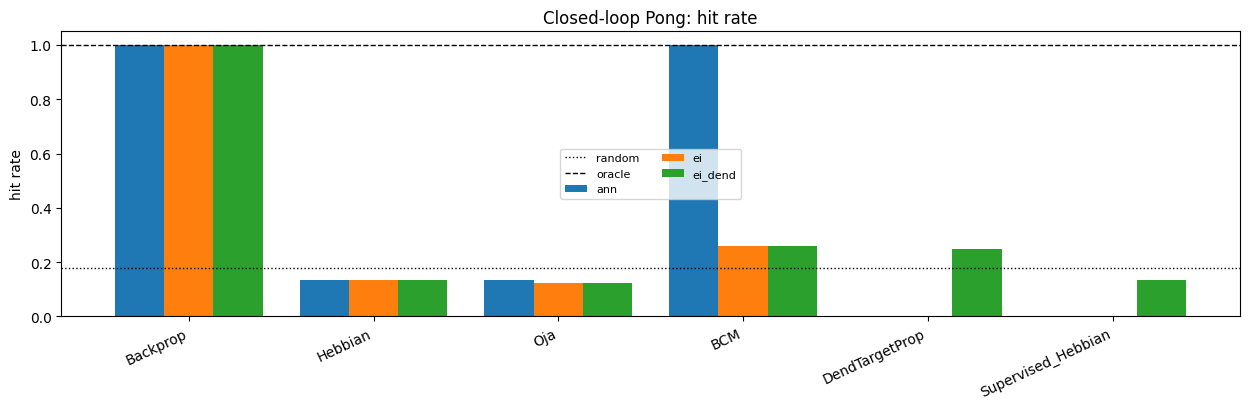

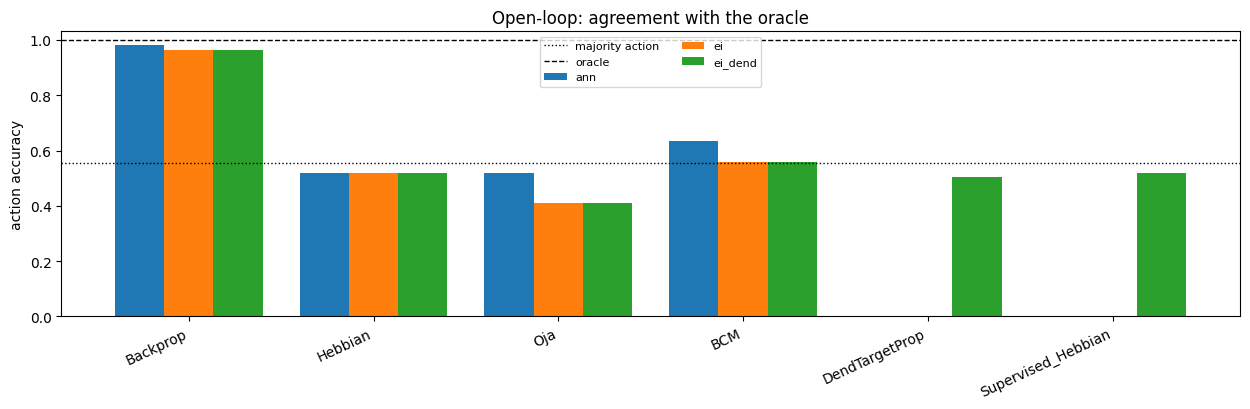

In [ ]:
plot_results(results, ARCHITECTURES, LEARNING_RULES, 'hit_rate',
             'Closed-loop Pong: hit rate')
plot_results(results, ARCHITECTURES, LEARNING_RULES, 'acc',
             'Open-loop: agreement with the oracle')

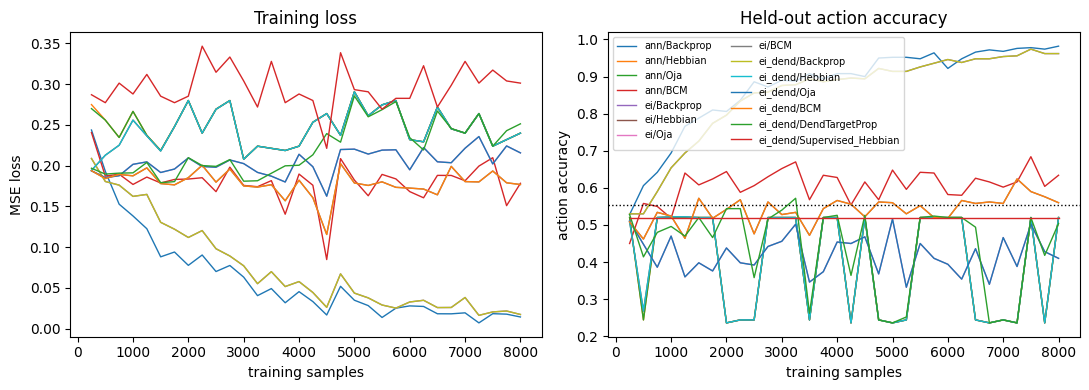

In [ ]:
plot_learning_curves(results, ARCHITECTURES, LEARNING_RULES)

### Diagnostics

These three cells are the most useful part of the notebook if you want to push the
local rules further — they tell you *where* credit assignment is breaking down
rather than just that the accuracy is low.

`gradient_alignment` is the decisive one. Dendritic target propagation is a
feedback-alignment scheme: it works only if the locally-computed error correlates
with the error true backprop would deliver. A cosine of 1.0 would be backprop; 0.0
means the rule is doing work uncorrelated with the task.

In [ ]:
X, Y, Xv, Yv = results['_data']
dend_net = results['ei_dend']['Hebbian']['net']

print('Dendritic E/I balance after training:')
dendritic_report(dend_net, X, 80)

print('\nCredit-assignment quality:')
gradient_alignment(dend_net, X, Y, 100)

# (The same measurement on the Backprop network returns ~0 by construction:
#  Backprop has no dendritic backward pass, so the dendritic state never moves.)

Dendritic E/I balance after training:
  H1.E       forward dendritic state: mean=-0.005  sd=0.053   (balanced means mean ~ 0 and sd > 0)
  H2.E       forward dendritic state: mean=-0.028  sd=0.065   (balanced means mean ~ 0 and sd > 0)

Credit-assignment quality:
  cos(local dendritic error, backprop error) = +0.000


0.0

In [ ]:
X, Y, Xv, Yv = results['_data']
dend_net = results['ei_dend']['Oja']['net']

print('Dendritic E/I balance after training:')
dendritic_report(dend_net, X, 80)

print('\nCredit-assignment quality:')
gradient_alignment(dend_net, X, Y, 100)

# (The same measurement on the Backprop network returns ~0 by construction:
#  Backprop has no dendritic backward pass, so the dendritic state never moves.)

Dendritic E/I balance after training:
  H1.E       forward dendritic state: mean=+0.001  sd=0.225   (balanced means mean ~ 0 and sd > 0)
  H2.E       forward dendritic state: mean=-0.015  sd=0.164   (balanced means mean ~ 0 and sd > 0)

Credit-assignment quality:
  cos(local dendritic error, backprop error) = +0.000


0.0

In [ ]:
X, Y, Xv, Yv = results['_data']
dend_net = results['ei_dend']['BCM']['net']

print('Dendritic E/I balance after training:')
dendritic_report(dend_net, X, 80)

print('\nCredit-assignment quality:')
gradient_alignment(dend_net, X, Y, 100)

# (The same measurement on the Backprop network returns ~0 by construction:
#  Backprop has no dendritic backward pass, so the dendritic state never moves.)

Dendritic E/I balance after training:
  H1.E       forward dendritic state: mean=-0.044  sd=0.159   (balanced means mean ~ 0 and sd > 0)
  H2.E       forward dendritic state: mean=-0.002  sd=0.142   (balanced means mean ~ 0 and sd > 0)

Credit-assignment quality:
  cos(local dendritic error, backprop error) = +0.000


0.0

In [ ]:
X, Y, Xv, Yv = results['_data']
dend_net = results['ei_dend']['DendTargetProp']['net']

print('Dendritic E/I balance after training:')
dendritic_report(dend_net, X, 80)

print('\nCredit-assignment quality:')
gradient_alignment(dend_net, X, Y, 100)

# (The same measurement on the Backprop network returns ~0 by construction:
#  Backprop has no dendritic backward pass, so the dendritic state never moves.)

Dendritic E/I balance after training:
  H1.E       forward dendritic state: mean=-0.122  sd=0.828   (balanced means mean ~ 0 and sd > 0)
  H2.E       forward dendritic state: mean=-0.037  sd=0.202   (balanced means mean ~ 0 and sd > 0)

Credit-assignment quality:
  cos(local dendritic error, backprop error) = +0.010


0.010468218597816303

In [ ]:
X, Y, Xv, Yv = results['_data']
dend_net = results['ei_dend']['Supervised_Hebbian']['net']

print('Dendritic E/I balance after training:')
dendritic_report(dend_net, X, 80)

print('\nCredit-assignment quality:')
gradient_alignment(dend_net, X, Y, 100)

# (The same measurement on the Backprop network returns ~0 by construction:
#  Backprop has no dendritic backward pass, so the dendritic state never moves.)

Dendritic E/I balance after training:
  H1.E       forward dendritic state: mean=+0.622  sd=3.704   (balanced means mean ~ 0 and sd > 0)
  H2.E       forward dendritic state: mean=-0.000  sd=0.000   (balanced means mean ~ 0 and sd > 0)

Credit-assignment quality:
  cos(local dendritic error, backprop error) = +0.347


0.34686573001803184

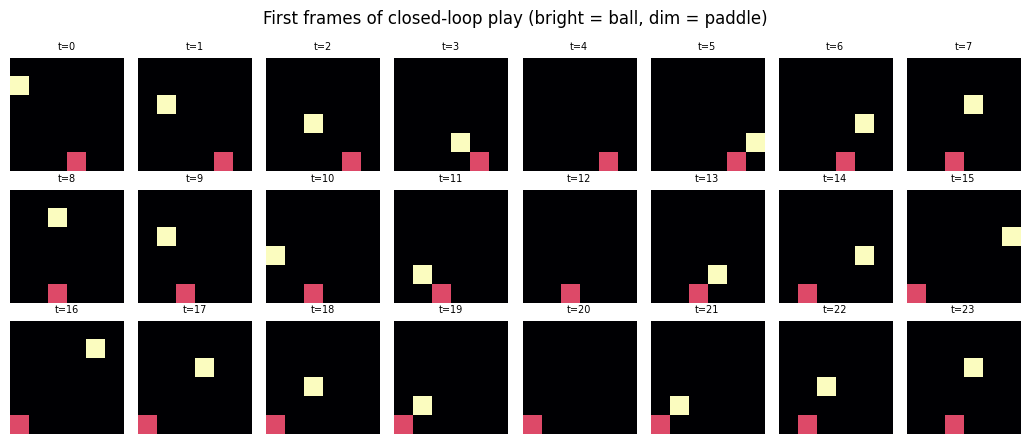

In [ ]:
# Watch a trained network actually play
render_episode(results['ann']['Backprop']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

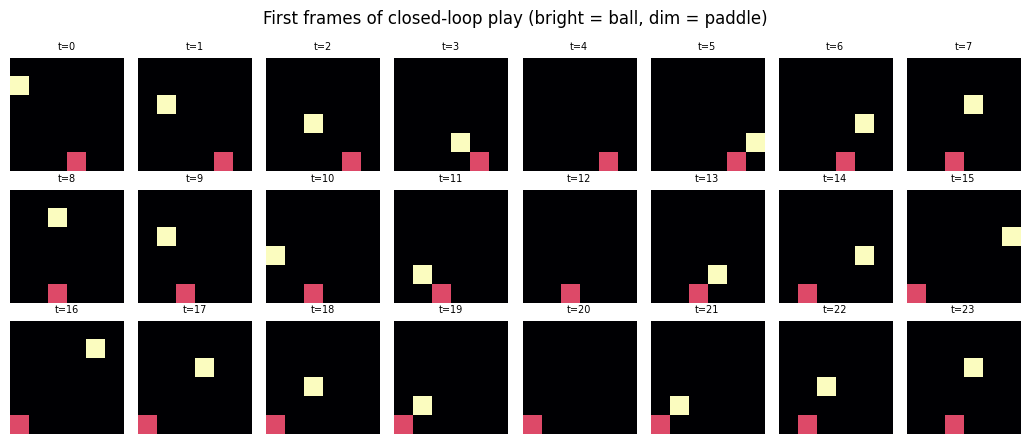

In [ ]:
# Watch a trained network actually play
render_episode(results['ei']['Backprop']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

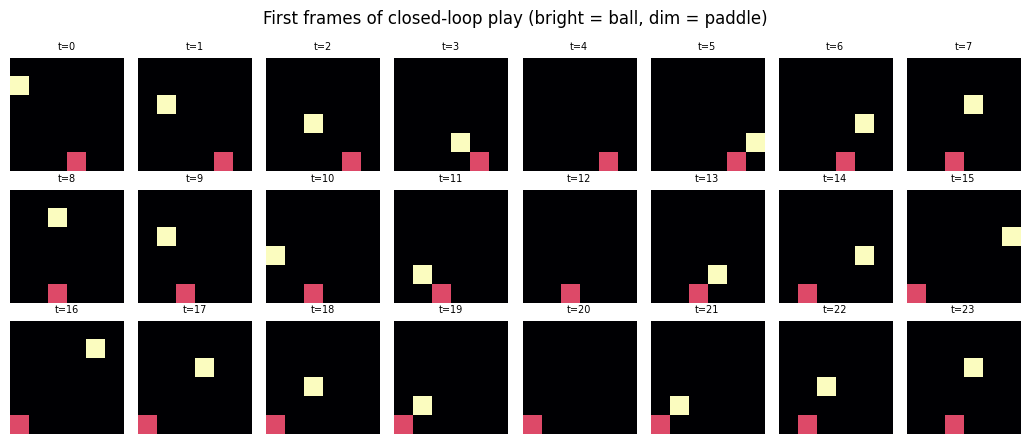

In [ ]:
# Watch a trained network actually play
render_episode(results['ei_dend']['Backprop']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

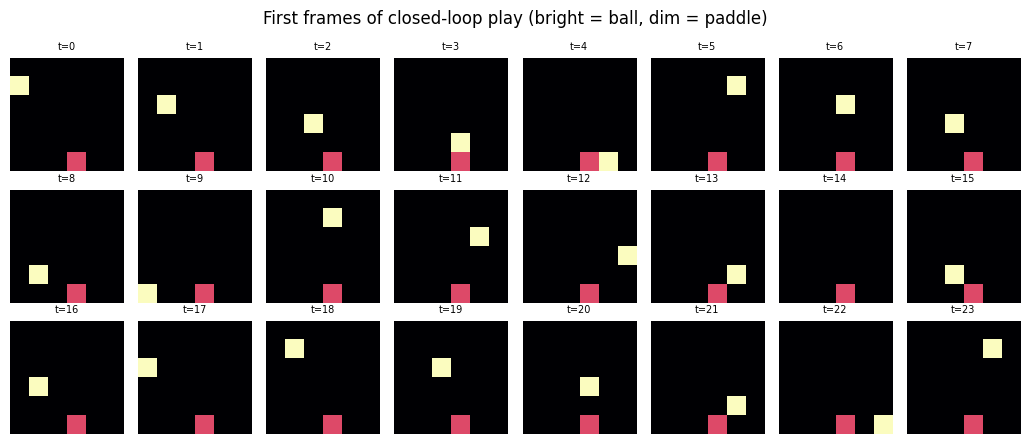

In [ ]:
# Watch a trained network actually play
render_episode(results['ann']['Hebbian']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

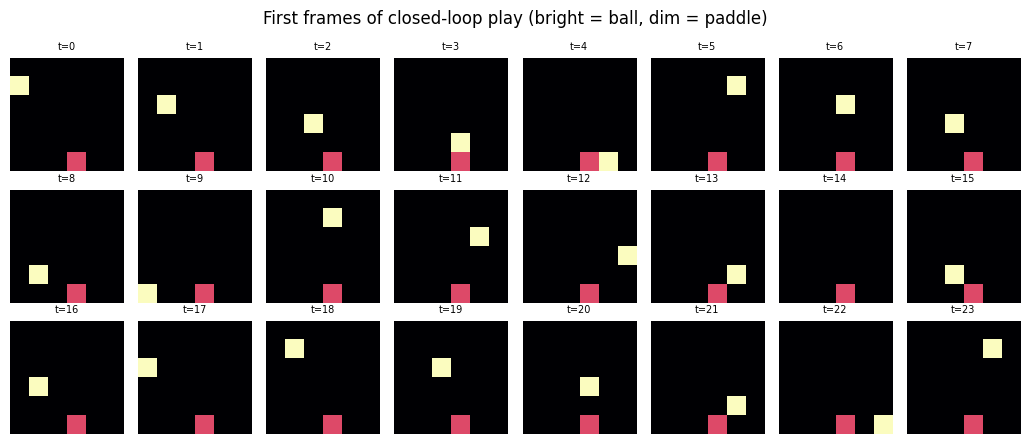

In [ ]:
# Watch a trained network actually play
render_episode(results['ei']['Hebbian']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

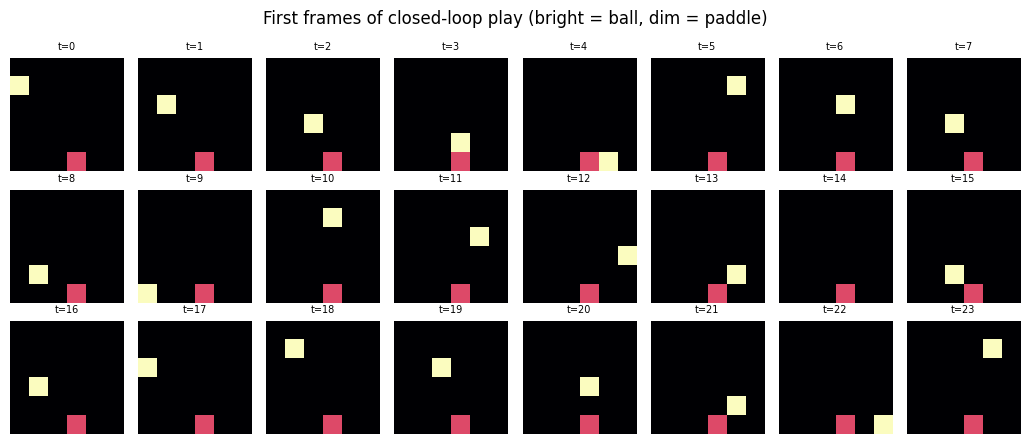

In [ ]:
# Watch a trained network actually play
render_episode(results['ei_dend']['Hebbian']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

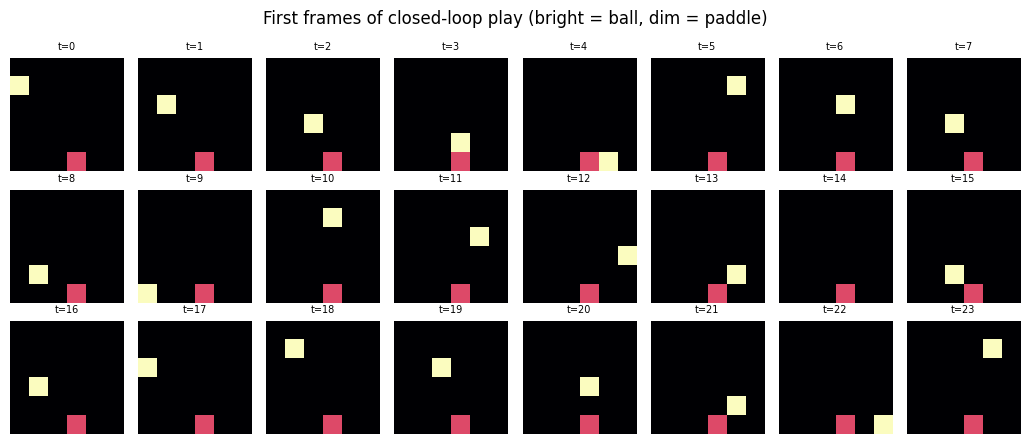

In [ ]:
# Watch a trained network actually play
render_episode(results['ann']['Oja']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

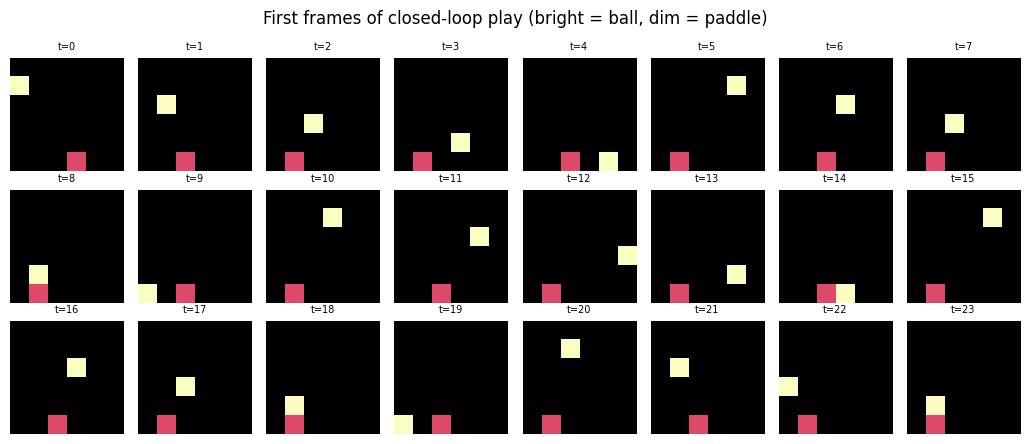

In [ ]:
# Watch a trained network actually play
render_episode(results['ei']['Oja']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

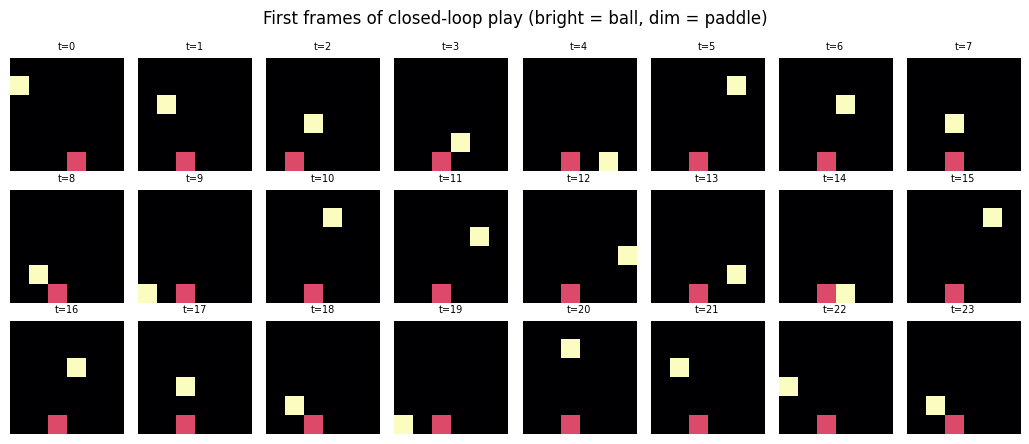

In [ ]:
# Watch a trained network actually play
render_episode(results['ei_dend']['Oja']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

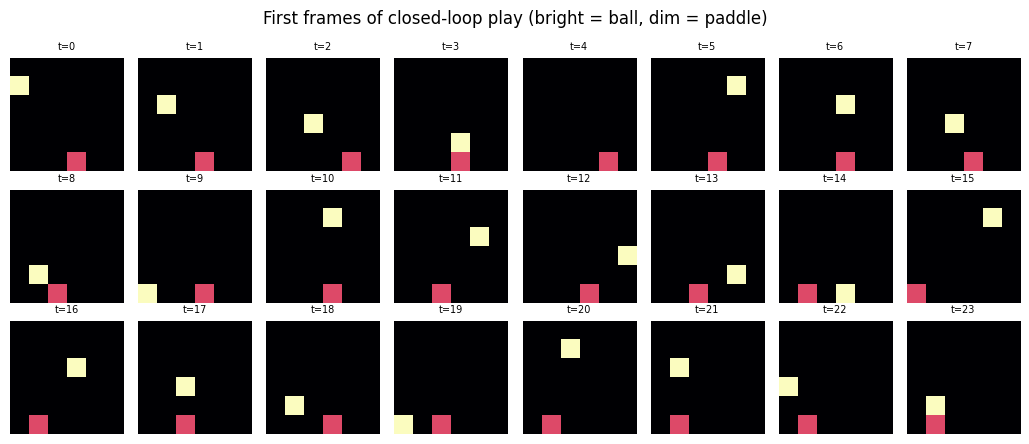

In [ ]:
# Watch a trained network actually play
render_episode(results['ann']['BCM']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

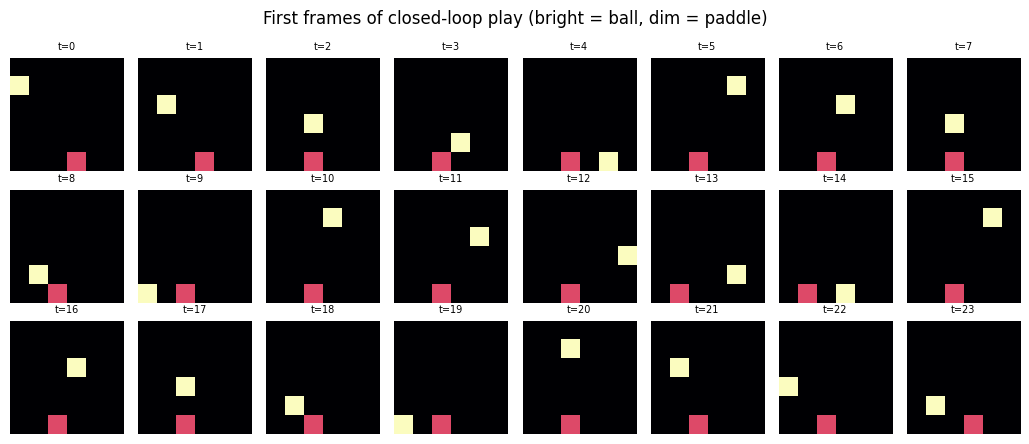

In [ ]:
# Watch a trained network actually play
render_episode(results['ei']['BCM']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

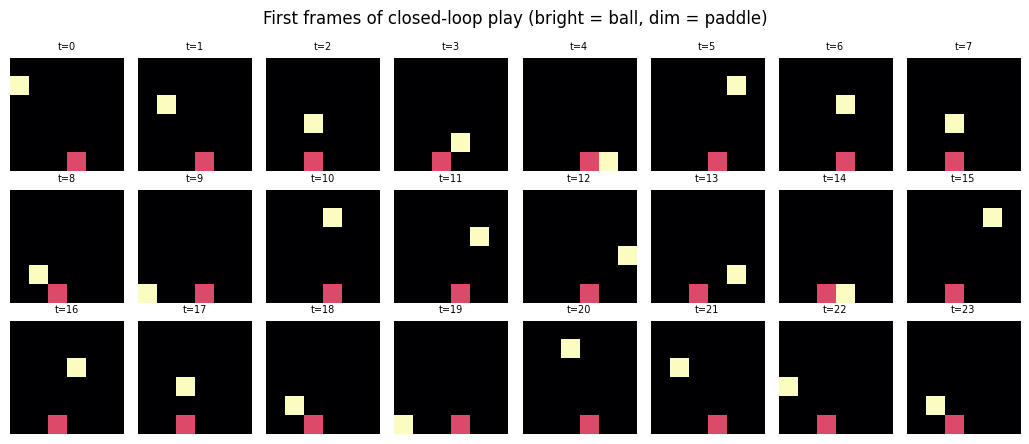

In [ ]:
# Watch a trained network actually play
render_episode(results['ei_dend']['BCM']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

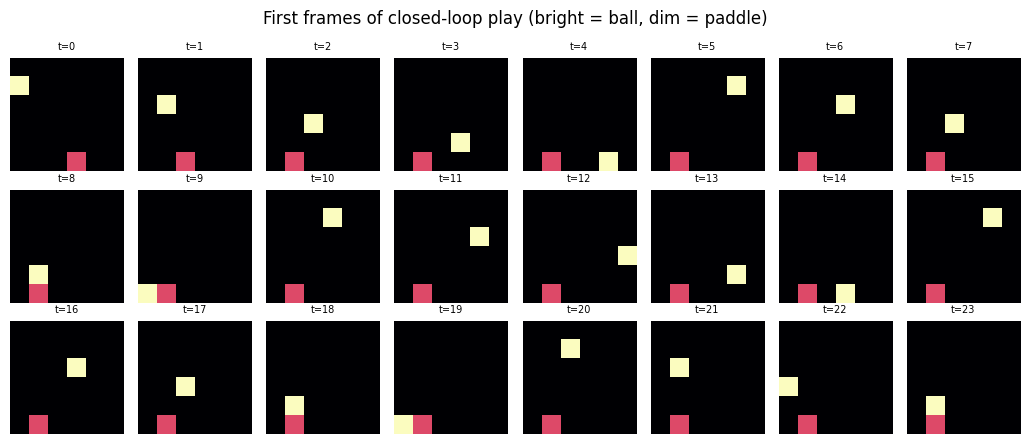

In [ ]:
# Watch a trained network actually play
render_episode(results['ei_dend']['DendTargetProp']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

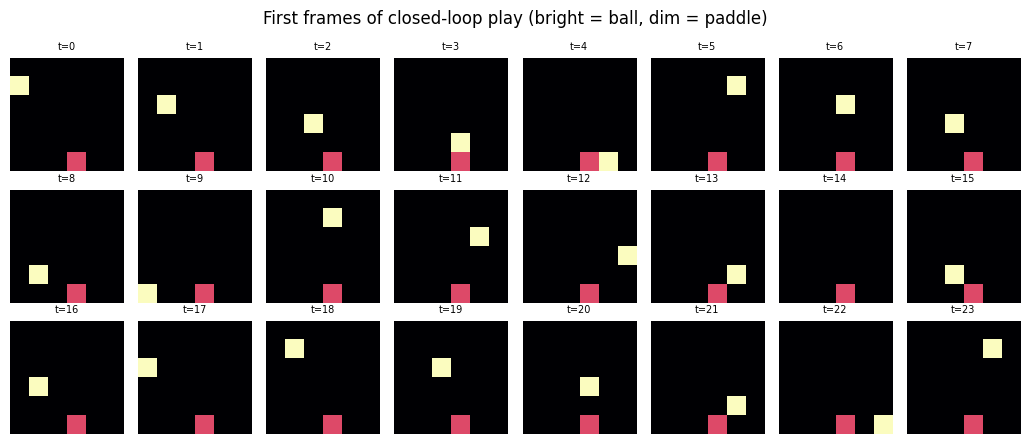

In [ ]:
# Watch a trained network actually play
render_episode(results['ei_dend']['Supervised_Hebbian']['net'],
               PongEnv(*PRESETS['easy'], obs_mode=CFG['obs_mode']), steps=60)

## Part 8 — Results, limitations, and how to push further

### What the numbers say

Backprop reaches ≈0.87 action accuracy and plays perfectly on all three
architectures, and the Dale-constrained `ei` network matches the unconstrained
`ann` here — the task is small enough that biological constraints cost little.
**Every local rule sits at or below the majority-action baseline** — several are
actively worse than predicting "stay" every time, which means they are not merely
failing to learn but degrading the representation.

That is not a bug in the plumbing, and the diagnostics say why. Three
measurements, in order of how much they explain:

1. **The output readout works.** Freezing the hidden layers and training only the
   output projection gives ≈0.58 with the local delta rule versus ≈0.62 with Adam.
   So the supervised output rule is fine; random hidden features simply cap
   performance at ≈0.62.
2. **The dendrite is healthy.** After calibration the forward dendritic state is
   centred near zero with a real spread, and the backward error is signed
   (≈55% positive) and ~6× larger than before calibration.
3. **But the error is uncorrelated with the task.** `gradient_alignment` returns
   ≈+0.05 to +0.13 — essentially zero. The hidden layers are being driven by a
   signal that is not the gradient, so their features do not improve on random.

### Why alignment fails here, specifically

Feedback alignment needs the forward weights to rotate into agreement with the
fixed top-down pathway. Under **Dale's law the forward weights are sign-constrained
and cannot rotate freely** — an excitatory synapse can be weakened toward zero but
never inverted — while the effective top-down matrix
`M = W_topdown − W_DendI·W_out→DendI` is mixed-sign by construction. The achievable
alignment is therefore structurally bounded well below 1.

Galloni et al.'s answer is to **learn the top-down weights** so that `M` tracks
`W_forwardᵀ` instead of the other way round (their Figure 8). That rule is
implemented here as `Top_Down_Hebbian_Temporal_Contrast` and is on by default
(`learn_topdown=True`), and it does move alignment from ≈0.03 to ≈0.13 — but not
far enough to change the accuracy inside this training budget.

### The honest caveat about hyperparameters

Galloni et al. tuned their models with [Nested](https://github.com/neurosutras/nested),
a multi-objective optimiser, on a cluster — their published configs are literally
named `..._complete_optimized`. The learning rates in `RULE_PRESETS` here come from
a hand sweep over a handful of values. **Do not read these results as a
reproduction of their paper's claims about biologically-plausible learning.** They
are a working, instrumented starting point.

### Knobs worth turning, roughly in order of expected payoff

1. `RULE_PRESETS[...]['lr']` — hidden and output learning rates, the single most
   sensitive setting. Use the search cell below.
2. `topdown_lr` and `learn_topdown` in `build_pong_network` — this is the mechanism
   that is supposed to fix alignment, and it is currently under-tuned.
3. `exc_scale` / `inh_scale` (defaults 2.0 / 0.3) — E/I balance. Hidden-layer mean
   activity around 0.1–0.2 works; check with `dendritic_report` and the activity
   statistics.
4. `max_pop_fraction` (default 0.2) — what fraction of hidden units may emit a
   plateau per sample. Galloni et al. use values as low as 0.025.
5. `CFG['n_train']` — the local rules are far less sample-efficient than backprop;
   10–20× more samples is not unreasonable.
6. Try `obs_mode='compact'` (5 inputs). Much easier, much faster, and a better
   place to debug a rule before moving back to pixels.

### Deviations from EIANN, stated plainly

* **Backward-phase ordering.** Within a layer, interneurons are relaxed *before*
  the E population reads its dendrite. EIANN updates them afterwards. With EIANN's
  ordering the Dend-I population lags a step behind the nudge and contributes
  nothing signed to the local error, and the hidden plateau is ~6× smaller.
* **`calibrate_dendritic_inhibition` has no EIANN counterpart.** It is a one-off
  scalar rescale of each Dend-I→E(dend) matrix at initialisation. Without it the
  dendrite saturates at the ±1 clamp and no error can be read off it.
* **No learned biases anywhere**, for all rules and architectures, so the
  comparison is not confounded by giving the backprop condition extra learned
  parameters. EIANN's own configs do use `bias_learning_rule: Backprop`; set
  `include_bias=True, bias_rule='Backprop'` to match them.
* **BTSP is not implemented.** `EIANN/rules/btsp.py` is a substantial module in its
  own right; `Dend Target Prop (BTSP)` from the paper is out of scope here.
* Batching, `store_dynamics`, conv populations, and the YAML config interface are
  all omitted.

In [ ]:
# --- optional: small hyperparameter search over one (arch, rule) pair ---------
# Not run by default.  Set RUN_SEARCH = True to use it.
RUN_SEARCH = True

def search(arch, rule, hidden_lrs, output_lrs, cfg=None, **build_kw):
    cfg = cfg or CFG
    env_kw = dict(width=cfg['width'], height=cfg['height'], obs_mode=cfg['obs_mode'])
    proto = PongEnv(**env_kw, rng=np.random.default_rng(0))
    Xs, Ys = generate_dataset(PongEnv(**env_kw, rng=np.random.default_rng(2)),
                              cfg['n_train'], epsilon=cfg['epsilon'], seed=2)
    Xq, Yq = generate_dataset(PongEnv(**env_kw, rng=np.random.default_rng(3)),
                              cfg['n_val'], epsilon=cfg['epsilon'], seed=3)
    best = None
    for hlr in hidden_lrs:
        for olr in output_lrs:
            net = build_pong_network(arch, rule, obs_dim=proto.obs_dim,
                                     hidden_size=cfg['hidden_size'],
                                     hidden_lr=hlr, output_lr=olr,
                                     seed=cfg['seed'], **build_kw)
            calibrate_dendritic_inhibition(net, Xs, cfg['n_calibrate'])
            train_network(net, Xs, Ys, verbose=False)
            acc = action_accuracy(net, Xq, Yq)
            align = None
            if arch == 'ei_dend':
                align = gradient_alignment(net, Xs, Ys, 60)
            print(f'  hidden_lr={hlr:<8} output_lr={olr:<8} acc={acc:.3f}')
            if best is None or acc > best[0]:
                best = (acc, hlr, olr, align)
    print(f'\nbest: acc={best[0]:.3f} at hidden_lr={best[1]}, output_lr={best[2]}')
    return best

if RUN_SEARCH:
    search('ei_dend', 'DendTargetProp',
           hidden_lrs=[0.01, 0.05, 0.2],
           output_lrs=[0.1, 0.5, 2.0])

  cos(local dendritic error, backprop error) = +0.104
  hidden_lr=0.01     output_lr=0.1      acc=0.560
  cos(local dendritic error, backprop error) = +0.102
  hidden_lr=0.01     output_lr=0.5      acc=0.564
  cos(local dendritic error, backprop error) = +0.035
  hidden_lr=0.01     output_lr=2.0      acc=0.520
  cos(local dendritic error, backprop error) = +0.205
  hidden_lr=0.05     output_lr=0.1      acc=0.520
  cos(local dendritic error, backprop error) = +0.018
  hidden_lr=0.05     output_lr=0.5      acc=0.504
  cos(local dendritic error, backprop error) = +0.065
  hidden_lr=0.05     output_lr=2.0      acc=0.520
  cos(local dendritic error, backprop error) = -0.074
  hidden_lr=0.2      output_lr=0.1      acc=0.520
  cos(local dendritic error, backprop error) = -0.075
  hidden_lr=0.2      output_lr=0.5      acc=0.520
  cos(local dendritic error, backprop error) = +0.103
  hidden_lr=0.2      output_lr=2.0      acc=0.520

best: acc=0.564 at hidden_lr=0.01, output_lr=0.5
